In [1]:
import sys
import argparse
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import numpy as np
import anndata
import statsmodels.api as sm
import statsmodels.formula.api as smf
import tqdm
import pandas as pd



import anndata
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy
from matplotlib.pyplot import rc_context
# --- MATPLOTLIB SETTINGS ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
rc_params = {
    "font.family": "sans-serif", # "text.usetex": True,
    "font.serif" : ['Arial'], # "font.size" : 6,
    "font.weight" : "normal",
    'xtick.labelsize' : 5,
    'ytick.labelsize' : 5,
    'legend.fontsize' : 5,
    'axes.labelsize' : 6,
    'axes.linewidth': 0.8,
    'lines.linewidth' : 1,
    'axes.titlesize' : 7 # figure.titlesize
}
matplotlib.rcParams.update(rc_params)
margins = {  #     vvv margin in inches
    "left"   :     0.2,
    'right' : 1.0,
    'bottom' : 0.15
}

import tempo


In [2]:

# --- INIT ---

# which data to use
head_folder = "/".join(os.getcwd().split("/")[:3])
data_head_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint' % head_folder
hvg_to_use = 'prior_knowledge_guided'

# get corresponding paths
adata_path = '%s/adata_qc_filtered.h5ad' % data_head_folder
hvg_folder = '%s/data_annotations/hvg/%s' % (data_head_folder,hvg_to_use)
scvi_res_folder = '%s/scvi_res' % hvg_folder
scvi_mean_embedding_df_path = '%s/scvi_mean_embedding.tsv' % scvi_res_folder
umap_path_out = '%s/scvi_mean_umap_embedding.tsv' % scvi_res_folder
cluster_resolution = 0.05
clustering_folder = '%s/clustering/res_%s' % (scvi_res_folder, str(cluster_resolution))
cluster_df_fileout = '%s/clusters.tsv' % (clustering_folder)


# # SMC subclusters
# clustering_folder = '%s/Dropbox/aorta_circadian_data/datasets/joint/data_annotations/hvg/transformed_X_outlier_variance/scvi_res/clustering/res_0.05/subclustering/res_0.5' % head_folder
# cluster_df_fileout = '%s/smc_subclusters.tsv' % (clustering_folder)



# settings
min_prop = 1e-7




In [3]:
# --- LOAD ADATA ---

adata = anndata.read_h5ad(adata_path)

adata


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [4]:
# --- ADD EMBEDDINGS TO ADATA ---



# ** load clusters **
cluster_df = pd.read_table(cluster_df_fileout,sep='\t',index_col='index')

# ** make sure everything in the same order
adata = adata[list(cluster_df.index)]


# ** add embeddings **
adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])
# adata.obs["cluster"] = np.array(cluster_df['smc_subcluster'])

adata


/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_23715/1264531170.py:13: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["cluster"] = np.array(cluster_df['leiden_scvi_cluster'])


AnnData object with n_obs × n_vars = 145271 × 32285
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2'

In [5]:
# --- GET THE UNIQUE DESCRIPTION AND CLUSTERS ---

descriptions = list(adata.obs['description'].unique())
clusters = sorted(list(adata.obs['cluster'].unique()))
clusters = list(filter(lambda x: ~np.isnan(x),clusters)) # get rid of NaN cluster (only relevant for SMC subcluster)
clusters = list(map(lambda x: int(x),clusters))


print("Unique descriptions:\n",descriptions)
print("Unique clusters:\n",clusters)


# --- LIMIT ADATA TO GENES THAT MEET MINIMUM PSEUDOBULK COUNT THRESHOLD ---


# ** get gene pseudobulk counts
adata.var['pseudobulk_count'] = np.array(np.sum(adata.X,axis=0)).flatten()

# ** get the number of cells in the smallest cell type
smallest_cell_type_adata = adata[adata.obs['cluster'] == np.max(clusters)]

# ** get pseudobulk cutoff **
pseudobulk_threshold = min_prop * np.sum(smallest_cell_type_adata.obs['lib_size'])

# ** limit adata to this **
adata = adata[:,adata.var['pseudobulk_count'] >= pseudobulk_threshold]


adata


Unique descriptions:
 ['male aligned bmal1-ko', 'male misaligned bmal1-control', 'female aligned bmal1-ko', 'female misaligned bmal1-control', 'male aligned bmal1-control', 'female aligned bmal1-control']
Unique clusters:
 [0, 1, 2, 3, 4, 5, 6, 7, 8]


View of AnnData object with n_obs × n_vars = 145271 × 26120
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'pseudobulk_count'

In [6]:
# --- MAKE THE FOLDER OUTS ---

# head folder
reg_head_folder = '%s/tempo' % clustering_folder
if not os.path.exists(reg_head_folder):
    os.makedirs(reg_head_folder)


# subfolders for each cluster / condition combo
cluster_description_folder_out_dict = {}
for cluster in clusters:
    cluster_reg_folder = '%s/cluster_%s' % (reg_head_folder,cluster)
    if not os.path.exists(cluster_reg_folder):
        os.makedirs(cluster_reg_folder)
    for description in descriptions:
        cluster_description_reg_folder = '%s/%s' % (cluster_reg_folder,description)
        if not os.path.exists(cluster_description_reg_folder):
            os.makedirs(cluster_description_reg_folder)
            
        # update dict
        if cluster not in cluster_description_folder_out_dict:
            cluster_description_folder_out_dict[cluster] = {}
        cluster_description_folder_out_dict[cluster][description] = cluster_description_reg_folder

    
    

In [7]:
# # --- FIT ---


# import torch
# import tempo2
# from tempo2 import identify_de_novo_cyclers

# failed_list = []
# # for cluster in clusters:
# for cluster in clusters[1:]:
#     for description in descriptions:
        
#         try:
        
#             print("----------------")
#             print("Cluster %s; Description %s" % (cluster,description))


#             # ** get cluster, condition adata **
#             cluster_condition_adata = adata[(adata.obs['cluster'] == cluster) & (adata.obs['description'] == description)]
#             cluster_condition_adata = cluster_condition_adata[:,genes_to_est]
#             # cluster_condition_adata = cluster_condition_adata[:,new_genes_to_est]
#             # cluster_condition_adata = cluster_condition_adata[:,['Dbp','Arntl','Myh11']]

            
#             # ** prep **
#             cluster_condition_adata.var['prop'] = np.array(np.sum(cluster_condition_adata.X,axis=0)).flatten() / np.sum(cluster_condition_adata.obs['lib_size'])
#             if 'log_L' not in adata.obs:
#                 cluster_condition_adata.obs['log_L'] = np.array(np.log(cluster_condition_adata.obs['lib_size']))
#             cluster_condition_adata = cluster_condition_adata[:,cluster_condition_adata.var['prop'] > 0]

            
            
#             # ** run **
#             tempo2.identify_de_novo_cyclers.run(adata = cluster_condition_adata,
#                 folder_out = cluster_description_folder_out_dict[cluster][description],
#                 num_grid_points = 4,
#                 phases_sampled = torch.Tensor(np.array(cluster_condition_adata.obs['phase'])).unsqueeze(1), # torch.Tensor(np.array(adata.obs['phase'])).unsqueeze(1),
#                 cell_phase_dist = None, # cell_posterior_obj, # cell_posterior_obj # cell_posterior_obj
#                 use_nb = True,
#                 log_mean_log_disp_coef= None,# None, torch.Tensor(np.array([-3.001958370208740234e+00, -1.134198158979415894e-01]))
#                 lr = 1e-1,
#                 num_waveform_est_cell_samples = 1,
#                 num_waveform_est_gene_samples = 1,
#                 num_bf_est_cell_samples = 5,
#                 num_bf_est_gene_samples = 5,
#                 vi_max_epochs = 300,
#                 vi_print_epoch_loss = True,
#                 vi_improvement_window = 5,
#                 vi_convergence_criterion = 1e-3,
#                 cosinor_zero_frac_num_samples_per_waveform = 100,
#                 num_waveform_bf_cell_samples = 5,
#                 num_waveform_bf_gene_samples = 5,
#                 )


            
            
            
 
            
#         except Exception as e:
#             print(e)
            
#             failed = '%s_%s' % (cluster,description)
#             failed_list.append(failed)
            
            
            
            


In [8]:

cluster = 0

# ** get number of cells to sample be time point **
unique_zt = [0,6,12,18]
cluster_adata = adata[adata.obs['cluster'] == cluster]
num_cells_to_subsample_per_time_point = np.inf
for description in descriptions:
    cluster_condition_adata = cluster_adata[(cluster_adata.obs['description'] == description)]
    for zt in unique_zt:
        cluster_condition_zt_adata = cluster_condition_adata[(cluster_condition_adata.obs['zt'] == zt)]
        if cluster_condition_zt_adata.shape[0] < num_cells_to_subsample_per_time_point:
            num_cells_to_subsample_per_time_point = cluster_condition_zt_adata.shape[0]

            
        

In [9]:
# --- GET RID OF THE KO DESCRIPTIONS ---
descriptions = [
 'male misaligned bmal1-control',
 'female misaligned bmal1-control',
 'male aligned bmal1-control',
 'female aligned bmal1-control']



In [150]:
import helper_functions
# core_clock_path = '%s/Desktop/sc_phase_inference/utils/core_clock_and_ubiq_genes.txt' % head_folder
core_clock_path = '%s/Desktop/sc_phase_inference/utils/core_clock_genes.txt' % head_folder

cluster_condition_adata = helper_functions.add_transformed_X_to_adata(cluster_condition_adata,pseudocount=1e-5)
with open(core_clock_path) as file_obj:
    genes = list(map(lambda x: x.replace("\n", ''),file_obj.readlines()))
    genes = list(filter(lambda x: x in cluster_condition_adata.var_names,genes))
    
    
    
    
    
import umap


n_components = 2
n_neighbors = 50
min_dist = 0.2

metric = 'euclidean'
umap_embedding = umap.UMAP(n_neighbors=n_neighbors,
                  metric=metric, n_components = n_components).fit_transform(cluster_condition_adata[:,genes].layers['X_transformed'])





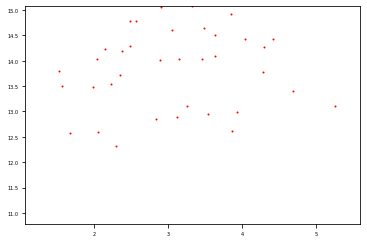

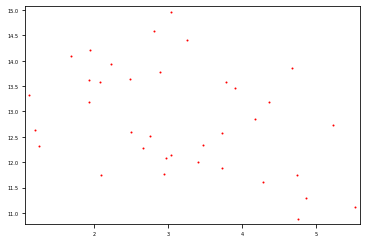

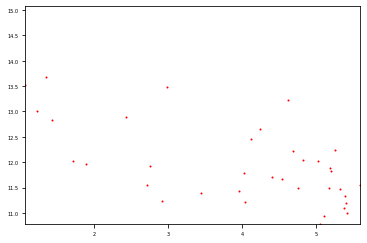

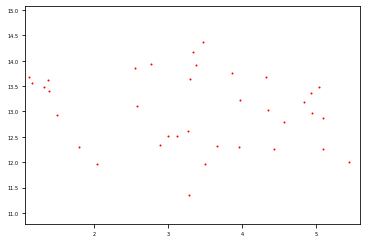

In [151]:
cluster_condition_adata.obsm['umap'] = umap_embedding
xlim = np.min(umap_embedding[:,0]), np.max(umap_embedding[:,0])
ylim = np.min(umap_embedding[:,1]), np.max(umap_embedding[:,1])



zt_cluster_condition_adata = cluster_condition_adata[cluster_condition_adata.obs['zt'] == 0]

plt.clf()
plt.scatter(zt_cluster_condition_adata.obsm['umap'][:,0],zt_cluster_condition_adata.obsm['umap'][:,1],c='r',s=1)
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()

zt_cluster_condition_adata = cluster_condition_adata[cluster_condition_adata.obs['zt'] == 6]

plt.clf()
plt.scatter(zt_cluster_condition_adata.obsm['umap'][:,0],zt_cluster_condition_adata.obsm['umap'][:,1],c='r',s=1)
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()


zt_cluster_condition_adata = cluster_condition_adata[cluster_condition_adata.obs['zt'] == 12]

plt.clf()
plt.scatter(zt_cluster_condition_adata.obsm['umap'][:,0],zt_cluster_condition_adata.obsm['umap'][:,1],c='r',s=1)
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()


zt_cluster_condition_adata = cluster_condition_adata[cluster_condition_adata.obs['zt'] == 18]

plt.clf()
plt.scatter(zt_cluster_condition_adata.obsm['umap'][:,0],zt_cluster_condition_adata.obsm['umap'][:,1],c='r',s=1)
plt.xlim(xlim)
plt.ylim(ylim)
plt.show()







In [10]:
# --- RUN TEMPO ---

import tempo
from tempo import unsupervised_alg

core_clock_path = '%s/Desktop/sc_phase_inference/utils/core_clock_genes.txt' % head_folder
clock_acrophase_prior_path = '%s/Desktop/sc_phase_inference/utils/clock_aorta_acrophase_prior.csv' % head_folder
folder_out = '/users/mingyaolab/desktop/test'


unique_zt = [0,6,12,18]


# for cluster in clusters:
for cluster in [1]:
    
    # ** get number of cells to sample be time point **
    cluster_adata = adata[adata.obs['cluster'] == cluster]
    num_cells_to_subsample_per_time_point = np.inf
    for description in descriptions:
        cluster_condition_adata = cluster_adata[(cluster_adata.obs['description'] == description)]
        for zt in unique_zt:
            cluster_condition_zt_adata = cluster_condition_adata[(cluster_condition_adata.obs['zt'] == zt)]
            if cluster_condition_zt_adata.shape[0] < num_cells_to_subsample_per_time_point:
                num_cells_to_subsample_per_time_point = cluster_condition_zt_adata.shape[0]

    
    for description in descriptions:
    # for description in ['female misaligned bmal1-control']:


        # ** get cluster, condition adata **
        cluster_condition_adata = cluster_adata[(cluster_adata.obs['description'] == description)]
        cluster_condition_adata.obs['log_L'] = np.array(np.log(cluster_condition_adata.obs['lib_size']))
        cluster_condition_adata.var['prop'] = np.array(np.sum(cluster_condition_adata.X,axis=0)).flatten() / np.sum(cluster_condition_adata.obs['lib_size'])


        # ** subsample **
#         barcodes_to_keep = []
#         for zt in unique_zt:
#             cluster_condition_zt_adata = cluster_condition_adata[(cluster_condition_adata.obs['zt'] == zt)]
#             sampled_barcodes = np.random.choice(cluster_condition_zt_adata.obs.index,size=num_cells_to_subsample_per_time_point,replace=False)
#             barcodes_to_keep += list(sampled_barcodes)
#         cluster_condition_adata = cluster_condition_adata[barcodes_to_keep,:]
        print(cluster_condition_adata)
        
        
        # ** run Tempo **
        tempo.unsupervised_alg.run(adata = cluster_condition_adata,
            folder_out = cluster_description_folder_out_dict[cluster][description],
            gene_acrophase_prior_path = clock_acrophase_prior_path,
            core_clock_gene_path = core_clock_path,
            reference_gene = 'Arntl', # 'Gene_0',
            min_gene_prop = 1e-5,
            max_num_alg_steps = 0,
            num_phase_grid_points = 24,
            num_phase_est_cell_samples = 10,
            num_phase_est_gene_samples = 10,
            num_harmonic_est_cell_samples = 3,
            num_harmonic_est_gene_samples = 3,
            use_nb = False,
            num_null_shuffles = 1,
            use_de_novo_cycler_detection = False,
            use_clock_input_only = True,
            use_clock_output_only = True)
        
        
            

/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/y2/0zd17m8j6bz5j5xv0cy2dw680000gp/T/ipykernel_23715/2634228612.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  cluster_condition_adata.obs['log_L'] = np.array(np.log(cluster_condition_adata.obs['lib_size']))


AnnData object with n_obs × n_vars = 1968 × 26120
    obs: 'sample_id', 'within_experiment_batch_id', 'lib_size', 'sex', 'misaligned', 'zt', 'bmal1_ko', 'batch', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'concat_batch', 'description', 'cluster', 'log_L'
    var: 'ensembl_id', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1', 'n_cells_by_counts-2', 'mean_counts-2', 'log1p_mean_counts-2', 'pct_dropout_by_counts-2', 'total_counts-2', 'log1p_total_counts-2', 'pseudobulk_count', 'prop'
--- RESTRICTING CANDIDATE HIGHLY VARIAB

/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tempo-0.0.1.dev0-py3.10.egg/tempo/unsupervised_alg.py:301: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['is_hv'] = False


Adata shape after thresholding based on gene variance
(1968, 804)
--- GENERATING NULL DISTRIBUTION OF CORE CLOCK EVIDENCE UNDER RANDOM CELL PHASE ASSIGNMENTS ---
clock_adata shape after thresholding based on gene variance
(1968, 25)


  0%|                                                                | 0/1 [00:00<?, ?it/s]/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tempo-0.0.1.dev0-py3.10.egg/tempo/objective_functions.py:175: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matricesor `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at  /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:2985.)


...

Adata shape after thresholding based on gene variance
(3469, 647)
--- GENERATING NULL DISTRIBUTION OF CORE CLOCK EVIDENCE UNDER RANDOM CELL PHASE ASSIGNMENTS ---
clock_adata shape after thresholding based on gene variance
(3469, 25)


  0%|                                                                | 0/1 [00:00<?, ?it/s]

Loss converged and stopping


100%|████████████████████████████████████████████████████████| 1/1 [00:53<00:00, 53.50s/it]
/Users/mingyaolab/opt/anaconda3/envs/misalignment/lib/python3.10/site-packages/tempo-0.0.1.dev0-py3.10.egg/tempo/prep.py:531: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


--- STARTING ALGORITHM ITERATION 0 --- 
--- ESTIMATING CELL PHASE POSTERIOR USING CURRENT CYCLERS ---
iter: 0; ELBO: 29941.50244140625; E[LL]: -29880.31494140625; KL: 61.186676025390625
iter: 1; ELBO: 28814.97216796875; E[LL]: -28732.615234375; KL: 82.35757446289062
iter: 2; ELBO: 28561.2255859375; E[LL]: -28457.701904296875; KL: 103.52401351928711
iter: 3; ELBO: 28200.20556640625; E[LL]: -28085.906982421875; KL: 114.29913711547852
iter: 4; ELBO: 27870.921875; E[LL]: -27753.811767578125; KL: 117.1096076965332
iter: 5; ELBO: 27896.9580078125; E[LL]: -27775.208740234375; KL: 121.74939346313477
iter: 6; ELBO: 27526.600830078125; E[LL]: -27400.43212890625; KL: 126.16884994506836
iter: 7; ELBO: 27823.93017578125; E[LL]: -27694.709228515625; KL: 129.22077178955078
iter: 8; ELBO: 27596.63525390625; E[LL]: -27465.66455078125; KL: 130.9705581665039
iter: 9; ELBO: 27347.89990234375; E[LL]: -27215.761962890625; KL: 132.13814544677734
iter: 10; ELBO: 27399.29443359375; E[LL]: -27266.63671875; KL: 

male misaligned bmal1-control


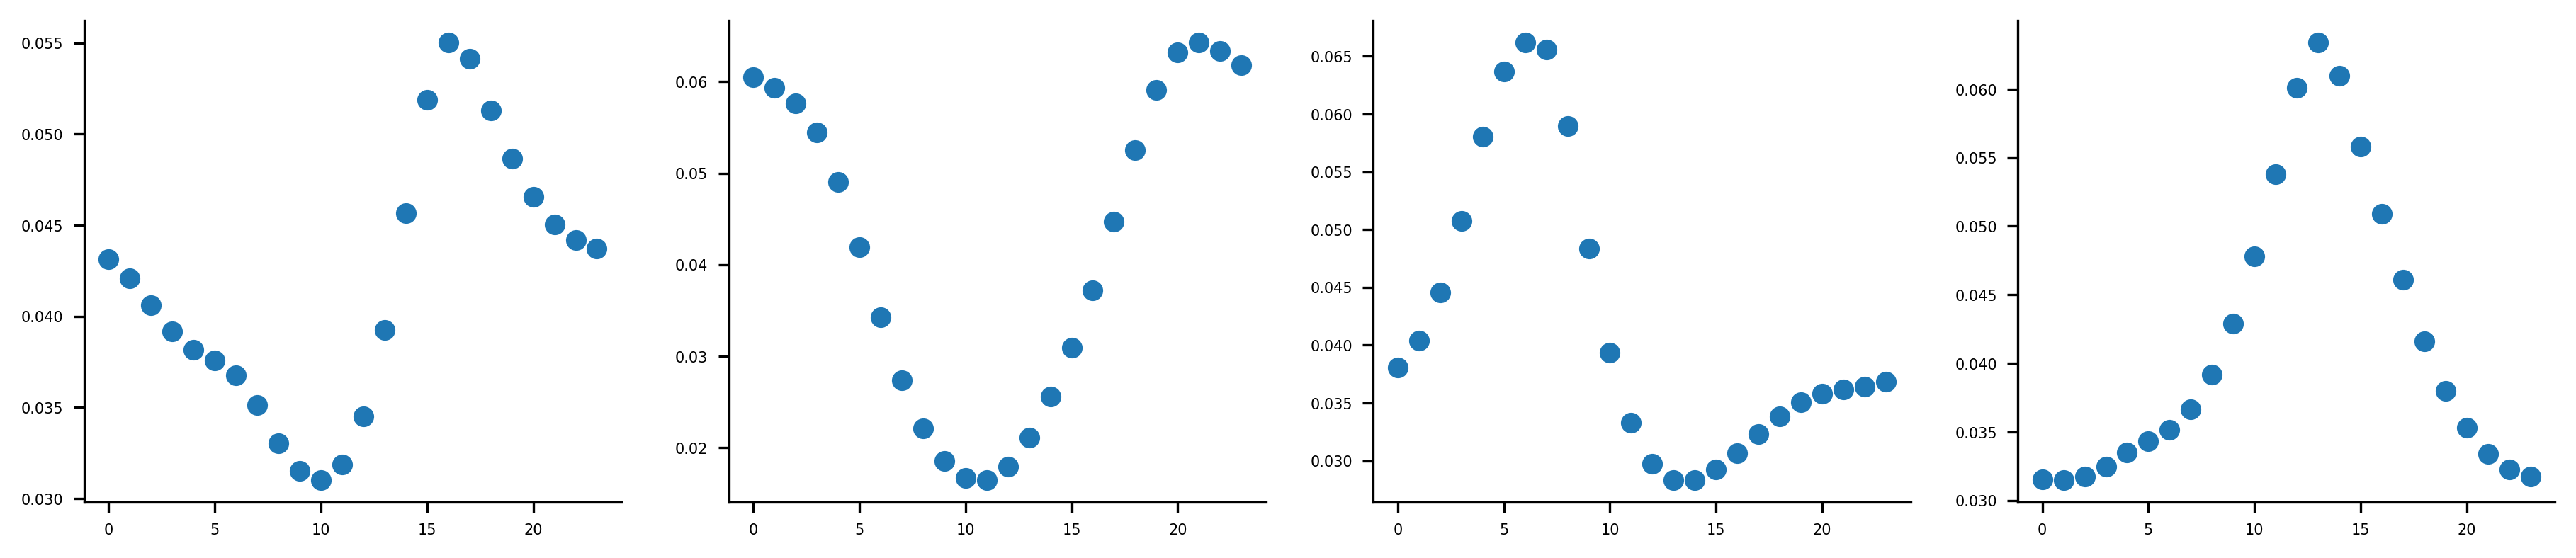

female misaligned bmal1-control


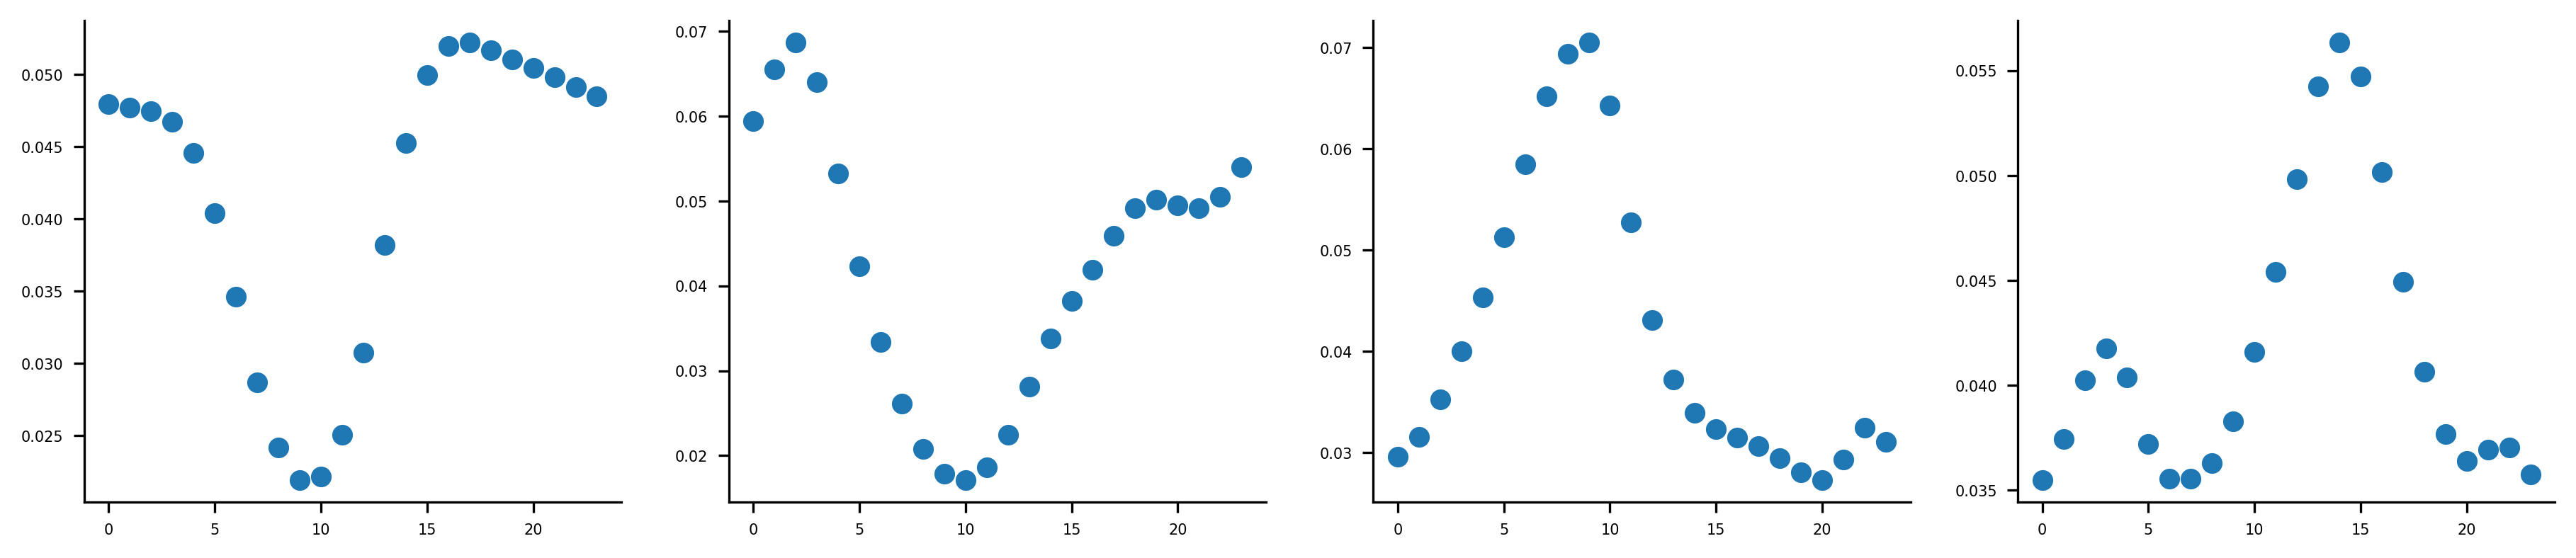

male aligned bmal1-control


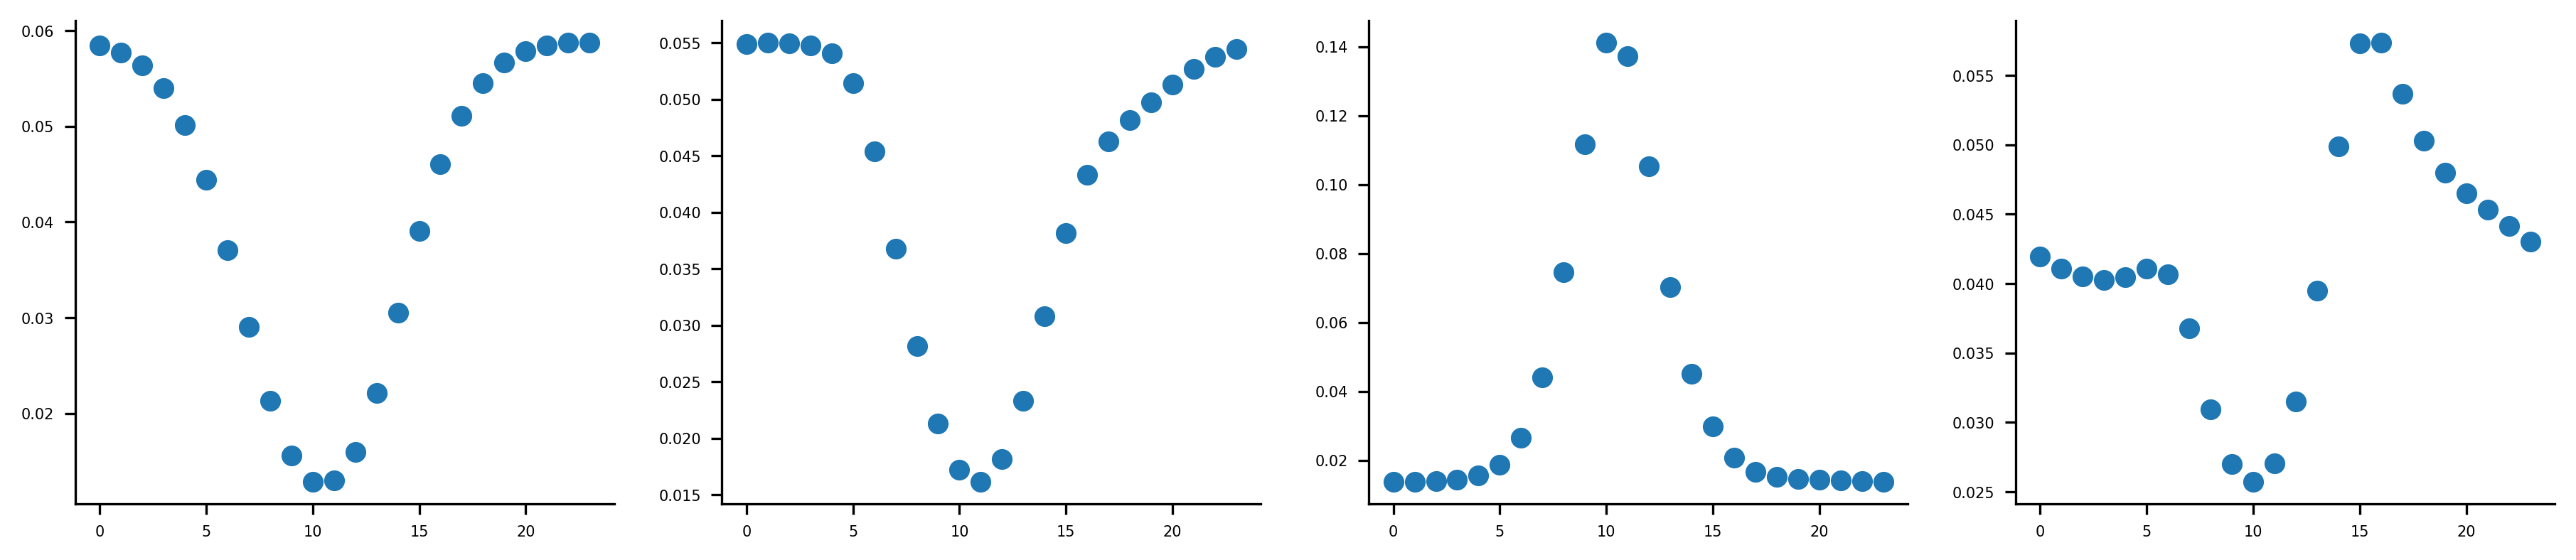

female aligned bmal1-control


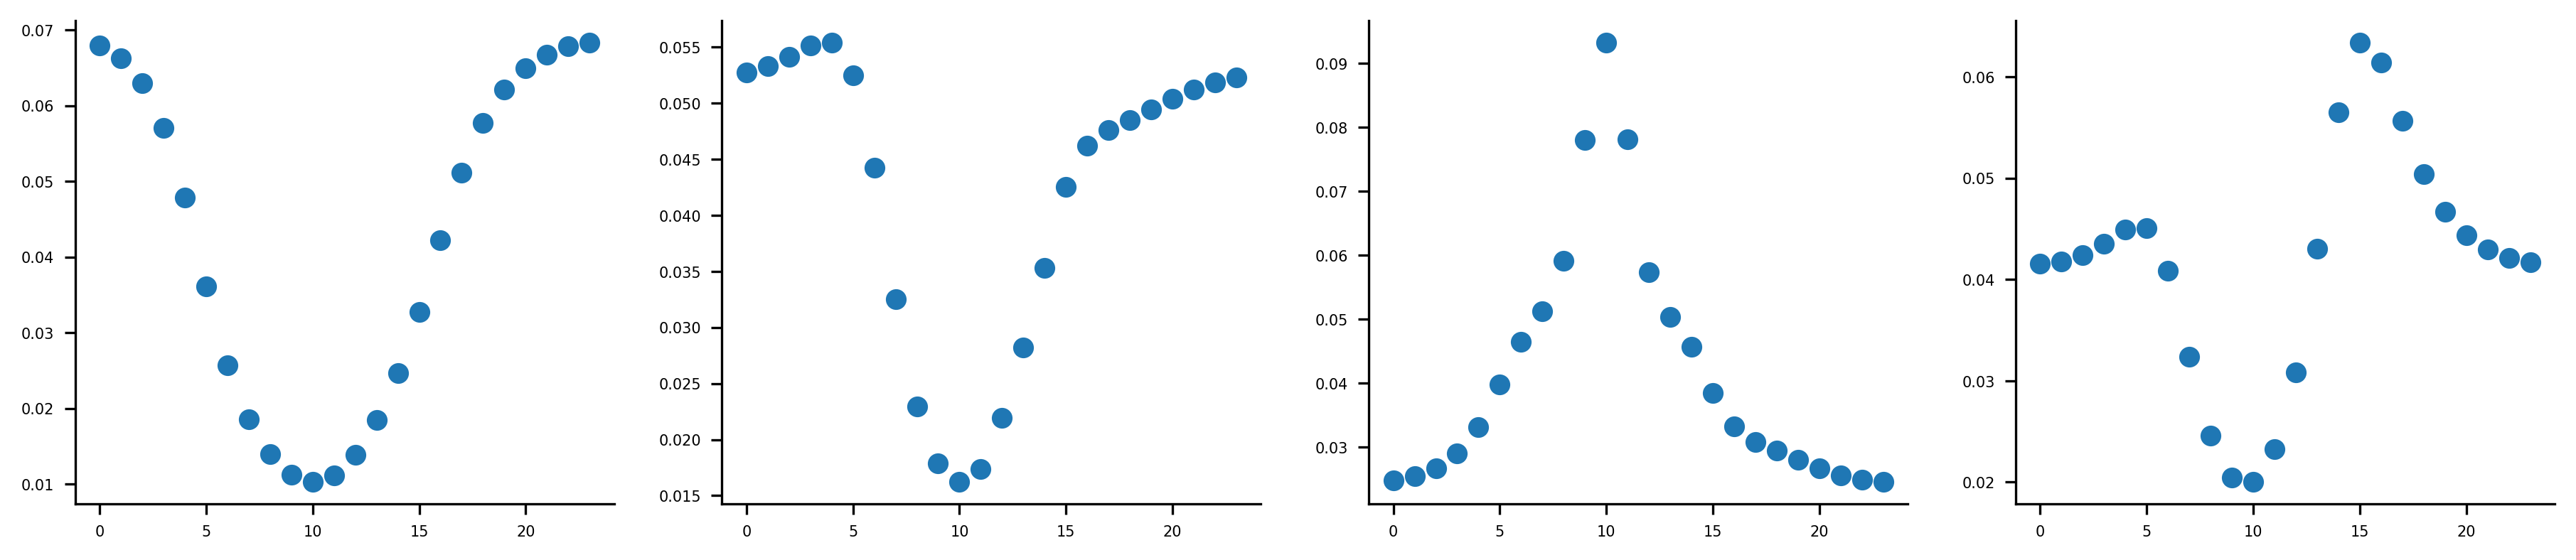

In [156]:
cluster = 3
for description in descriptions:
    
    print(description)
    
    # ** load the cell posterior **
    import torch
    from tempo import cell_posterior
    posterior_path = '%s/tempo_results/0/cell_phase_estimation/cell_posterior.tsv' % cluster_description_folder_out_dict[cluster][description]
    posterior_df = pd.read_table(posterior_path,sep='\t',index_col='barcode')
    posterior_obj = cell_posterior.ThetaPosteriorDist(torch.Tensor(np.array(posterior_df)))

    # ** get cluster condition adata **
    cluster_adata = adata[adata.obs['cluster'] == cluster]
    cluster_condition_adata = cluster_adata[(cluster_adata.obs['description'] == description)]


    # ** for each time point, get the pseudobulk posterior **
    unique_zt = [0,6,12,18]
    fig,axs = plt.subplots(figsize=(15,3), nrows=1,ncols=4,dpi=300)
    for zt_index,zt in enumerate(unique_zt):
        zt_cell_barcodes = list(set(cluster_condition_adata.obs[cluster_condition_adata.obs['zt'] == zt].index).intersection(set(posterior_df.index)))
        pseudobulk_density = np.array(np.sum(posterior_df.loc[zt_cell_barcodes],axis=0))
        pseudobulk_density = pseudobulk_density / np.sum(pseudobulk_density)
        axs[zt_index].scatter((posterior_obj.phase_grid.numpy() / np.pi) * 12.0, pseudobulk_density)
    sns.despine()
    plt.show()



male misaligned bmal1-control


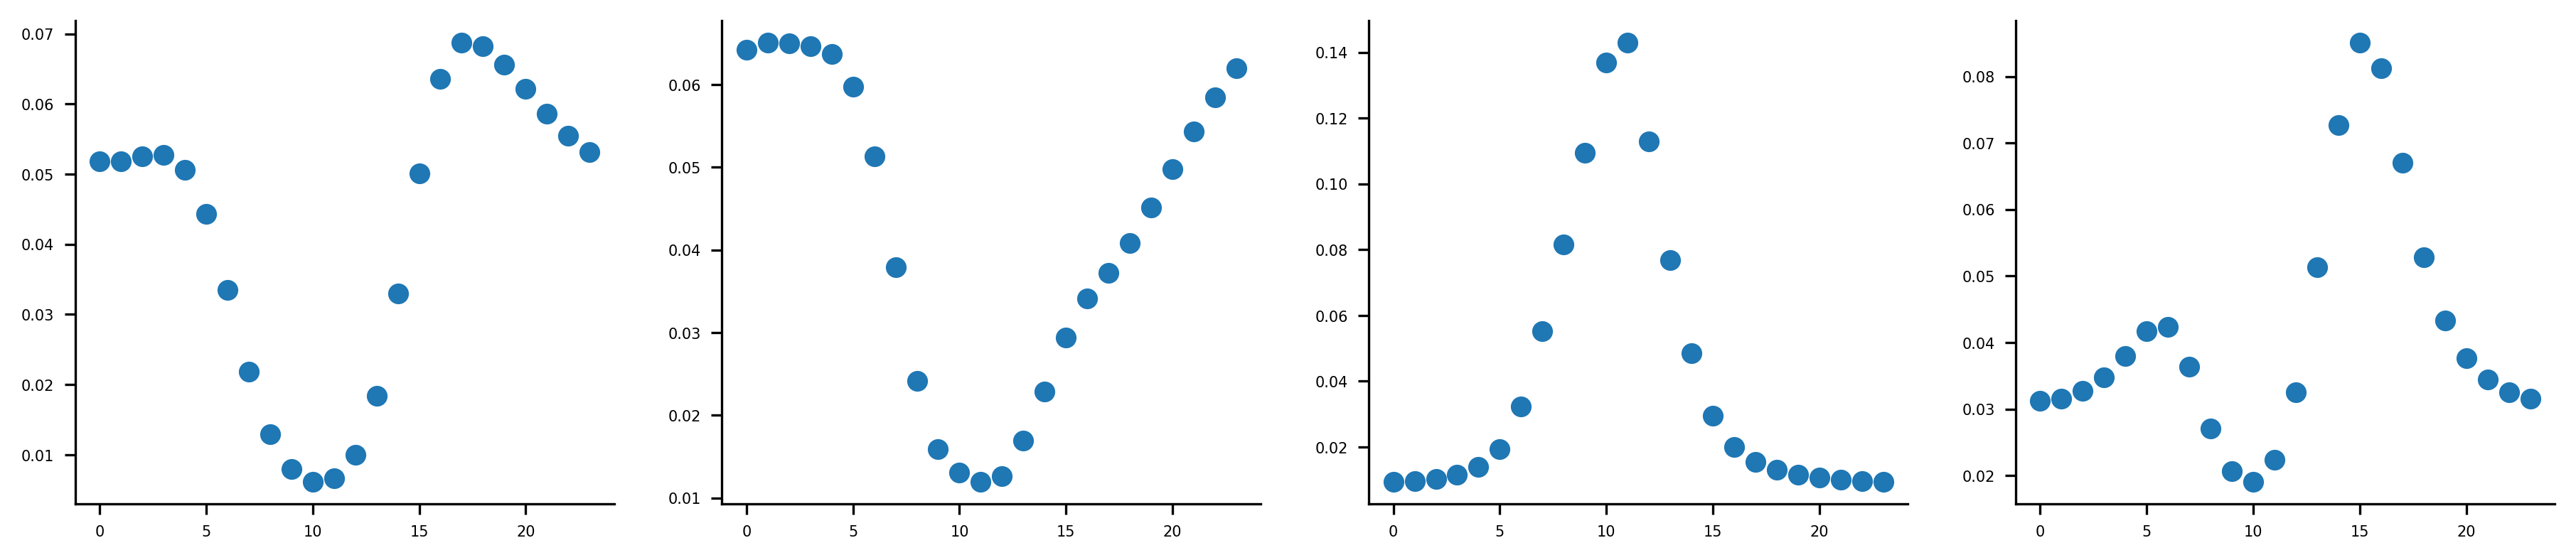

female misaligned bmal1-control


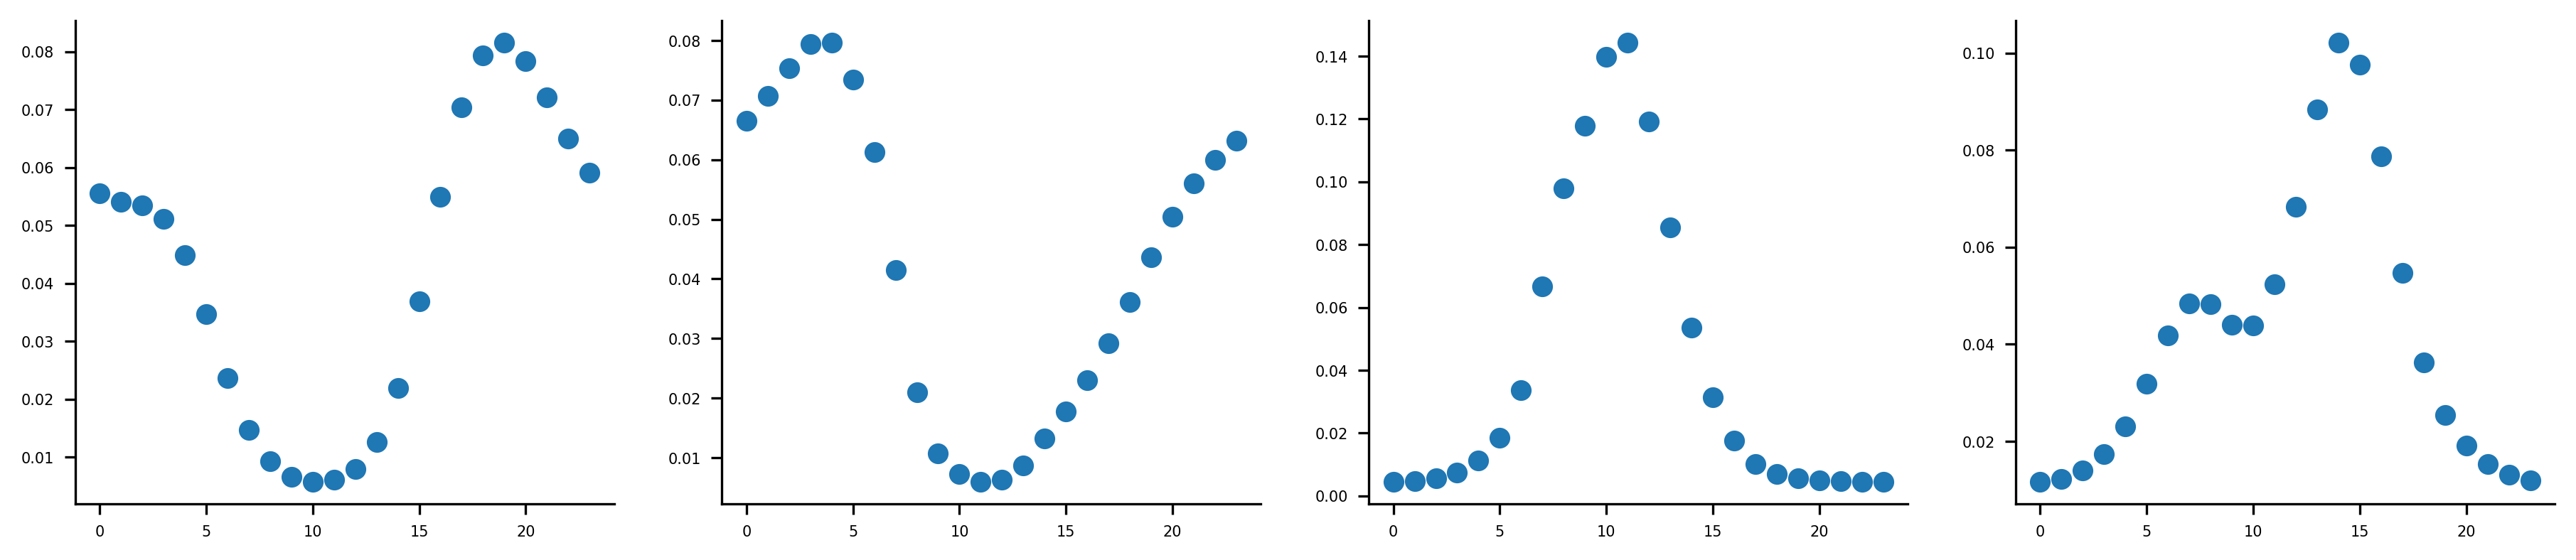

male aligned bmal1-control


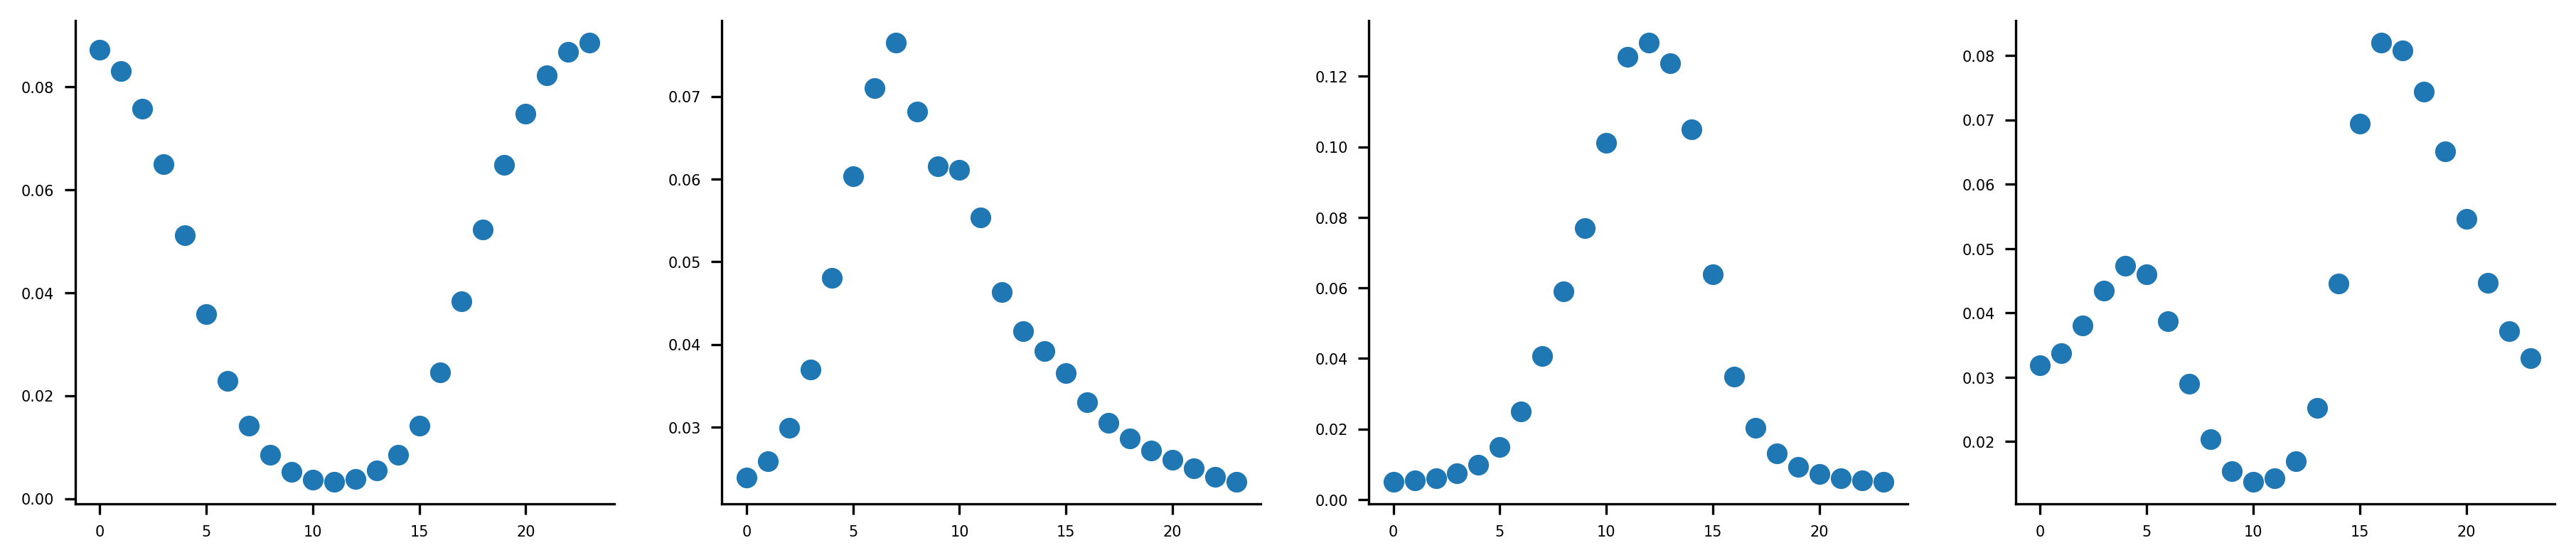

female aligned bmal1-control


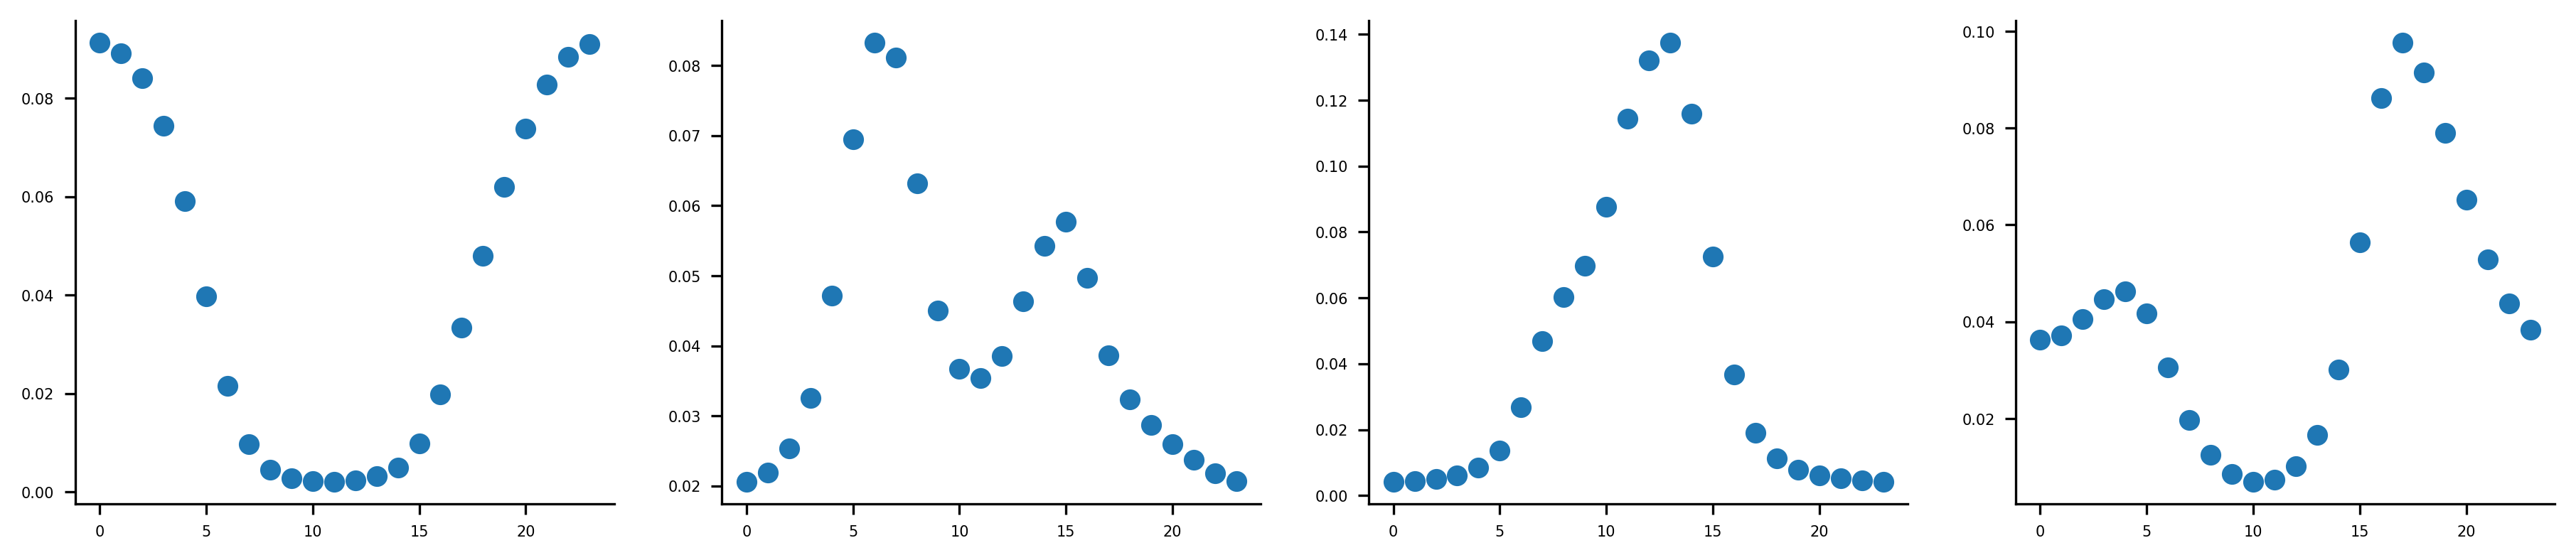

In [89]:
cluster = 1
for description in descriptions:
    
    print(description)
    
    # ** load the cell posterior **
    import torch
    from tempo import cell_posterior
    posterior_path = '%s/tempo_results/0/cell_phase_estimation/cell_posterior.tsv' % cluster_description_folder_out_dict[cluster][description]
    posterior_df = pd.read_table(posterior_path,sep='\t',index_col='barcode')
    posterior_obj = cell_posterior.ThetaPosteriorDist(torch.Tensor(np.array(posterior_df)))

    # ** get cluster condition adata **
    cluster_adata = adata[adata.obs['cluster'] == cluster]
    cluster_condition_adata = cluster_adata[(cluster_adata.obs['description'] == description)]


    # ** for each time point, get the pseudobulk posterior **
    unique_zt = [0,6,12,18]
    fig,axs = plt.subplots(figsize=(15,3), nrows=1,ncols=4,dpi=300)
    for zt_index,zt in enumerate(unique_zt):
        zt_cell_barcodes = list(set(cluster_condition_adata.obs[cluster_condition_adata.obs['zt'] == zt].index).intersection(set(posterior_df.index)))
        pseudobulk_density = np.array(np.sum(posterior_df.loc[zt_cell_barcodes],axis=0))
        pseudobulk_density = pseudobulk_density / np.sum(pseudobulk_density)
        axs[zt_index].scatter((posterior_obj.phase_grid.numpy() / np.pi) * 12.0, pseudobulk_density)
    sns.despine()
    plt.show()



male misaligned bmal1-control


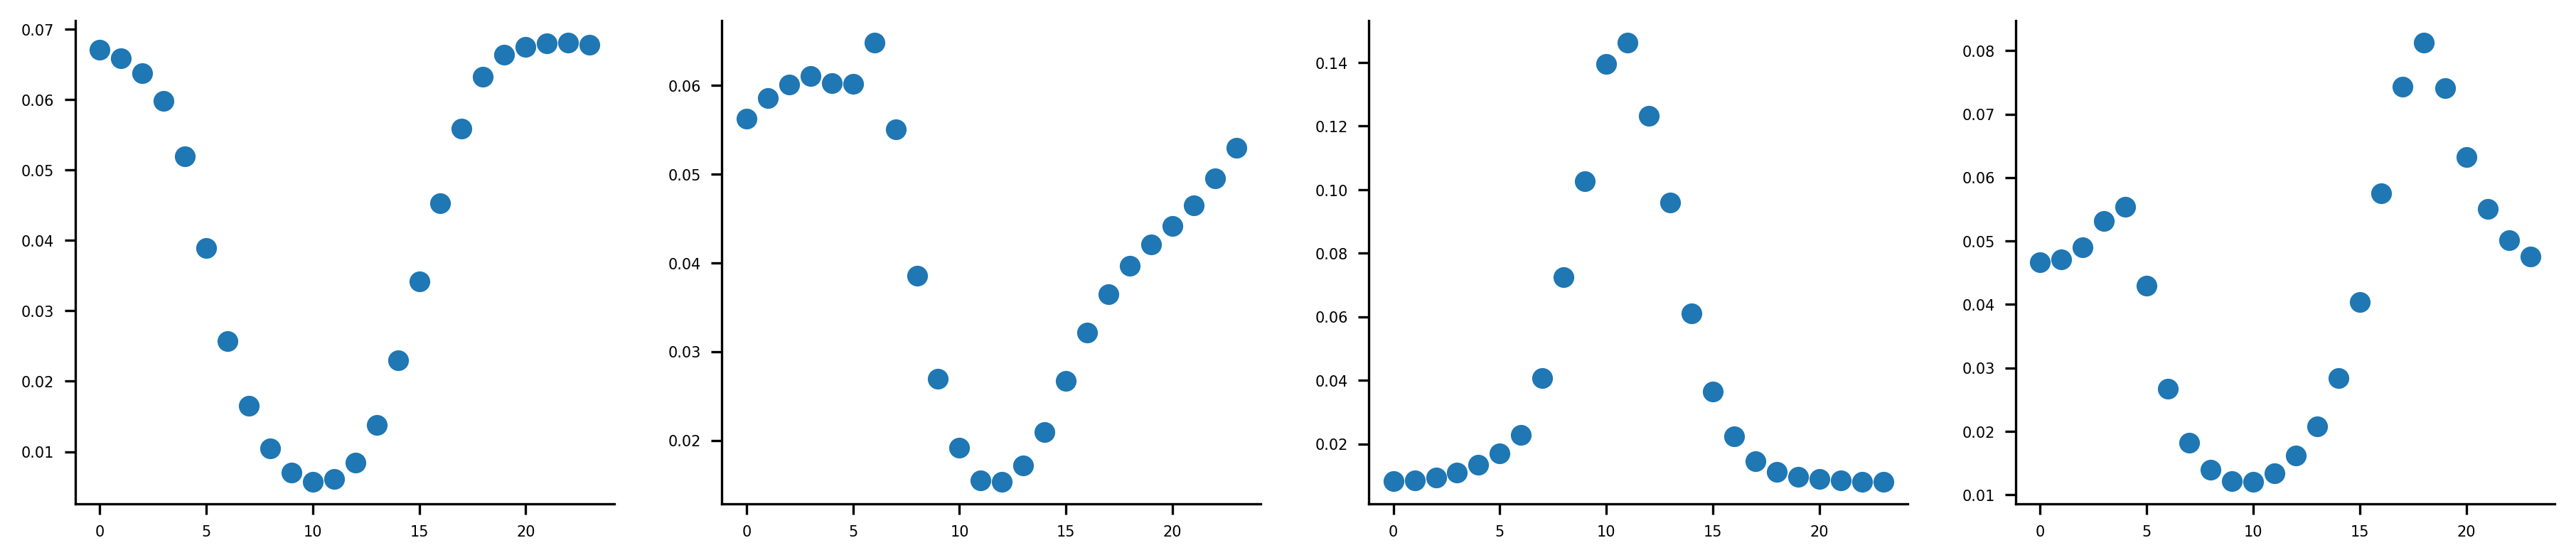

female misaligned bmal1-control


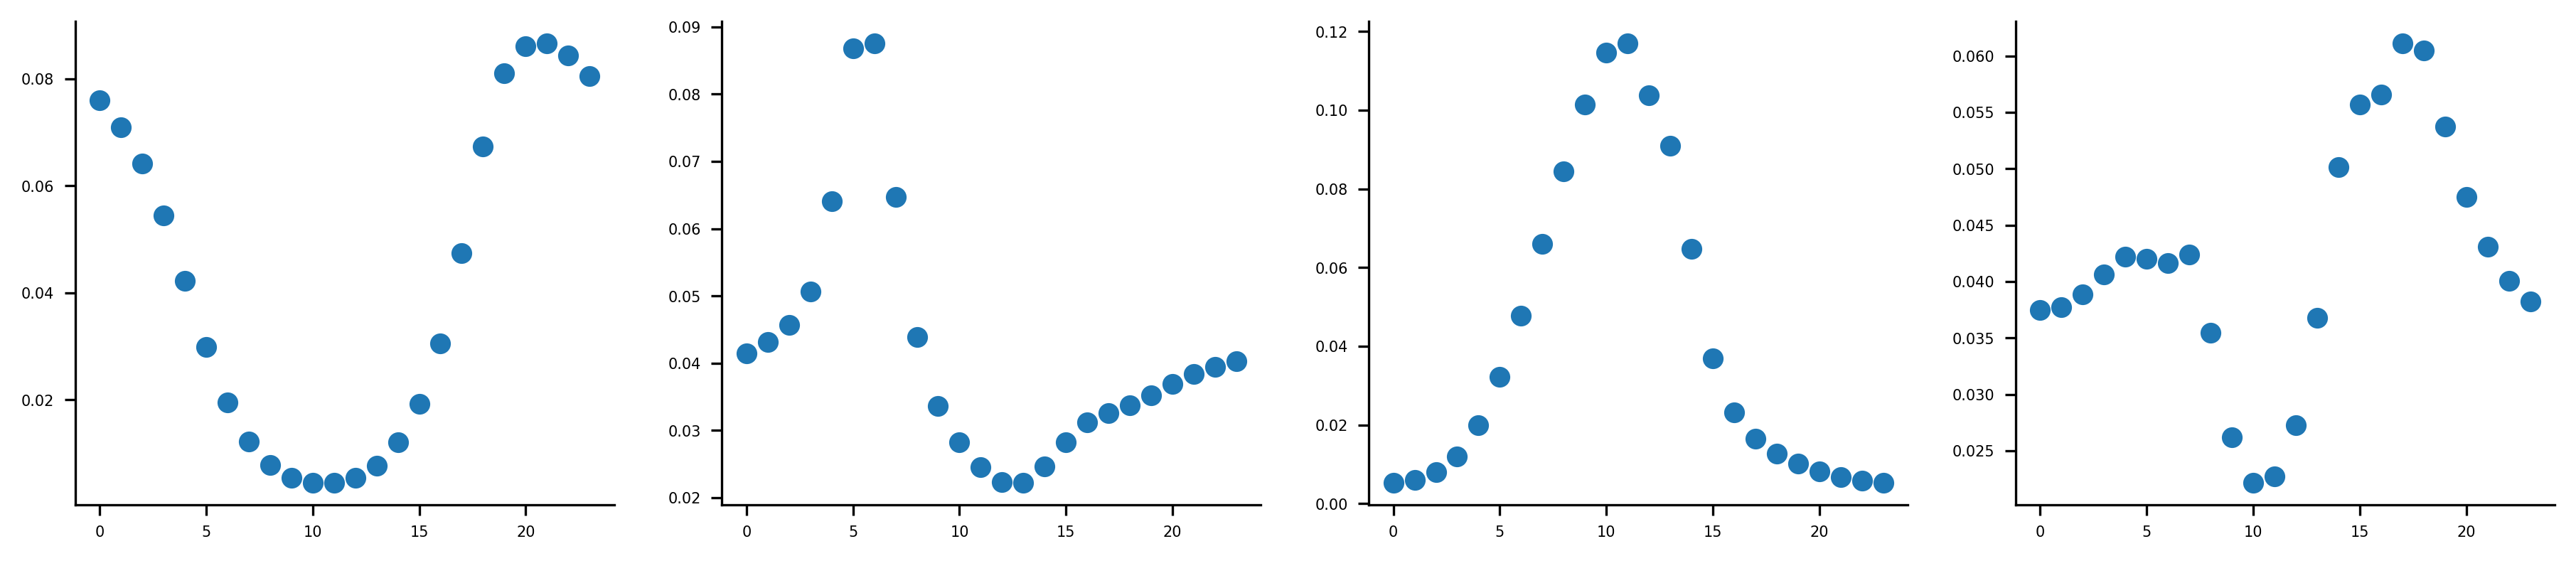

male aligned bmal1-control


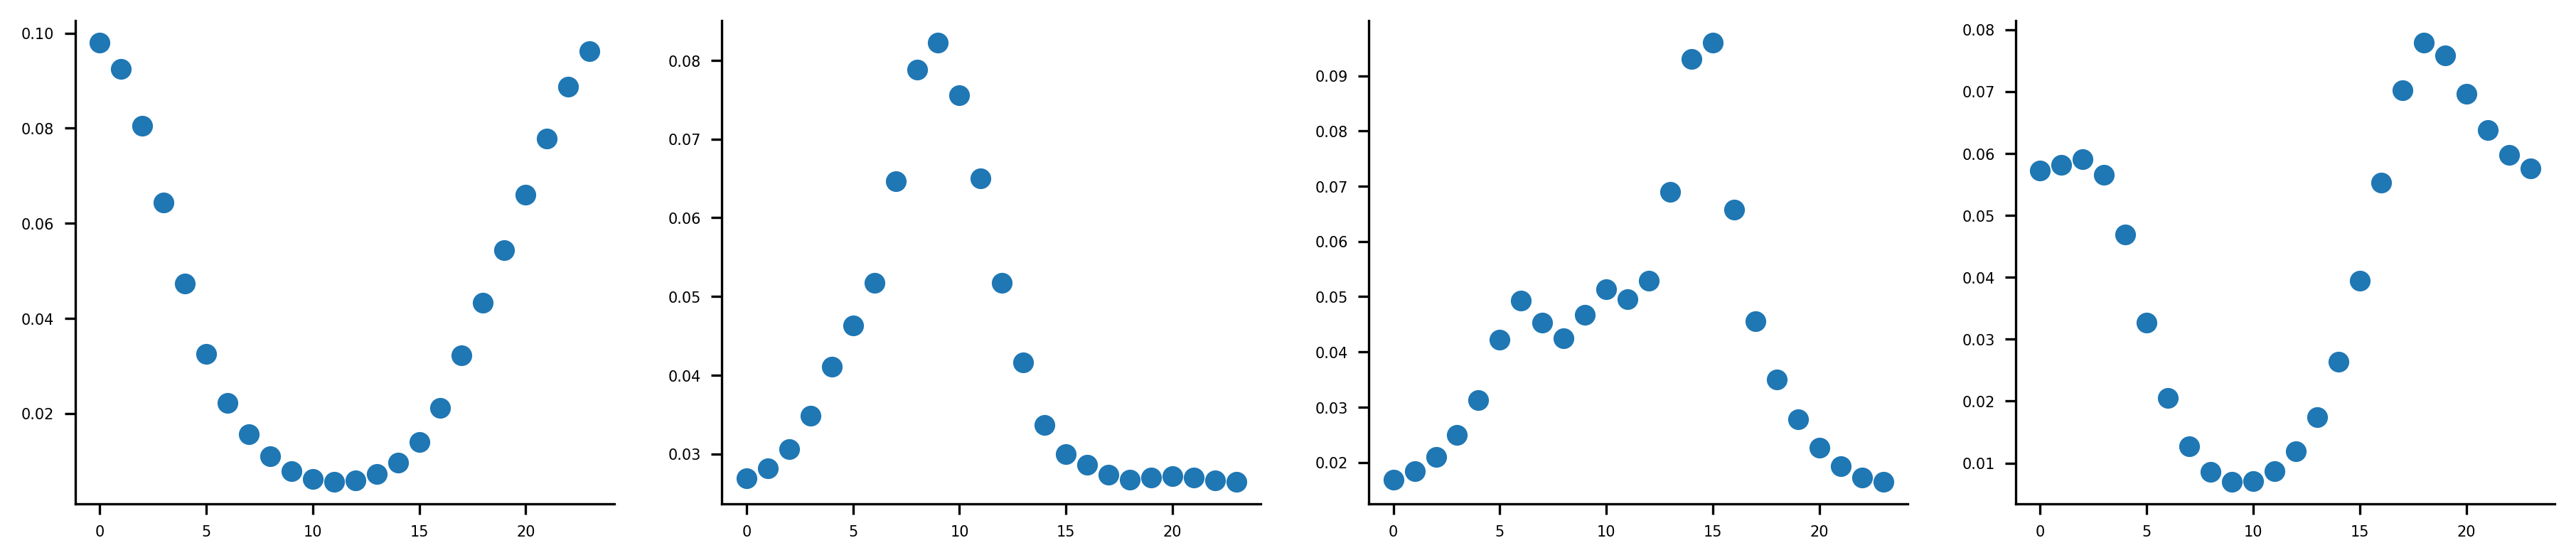

female aligned bmal1-control


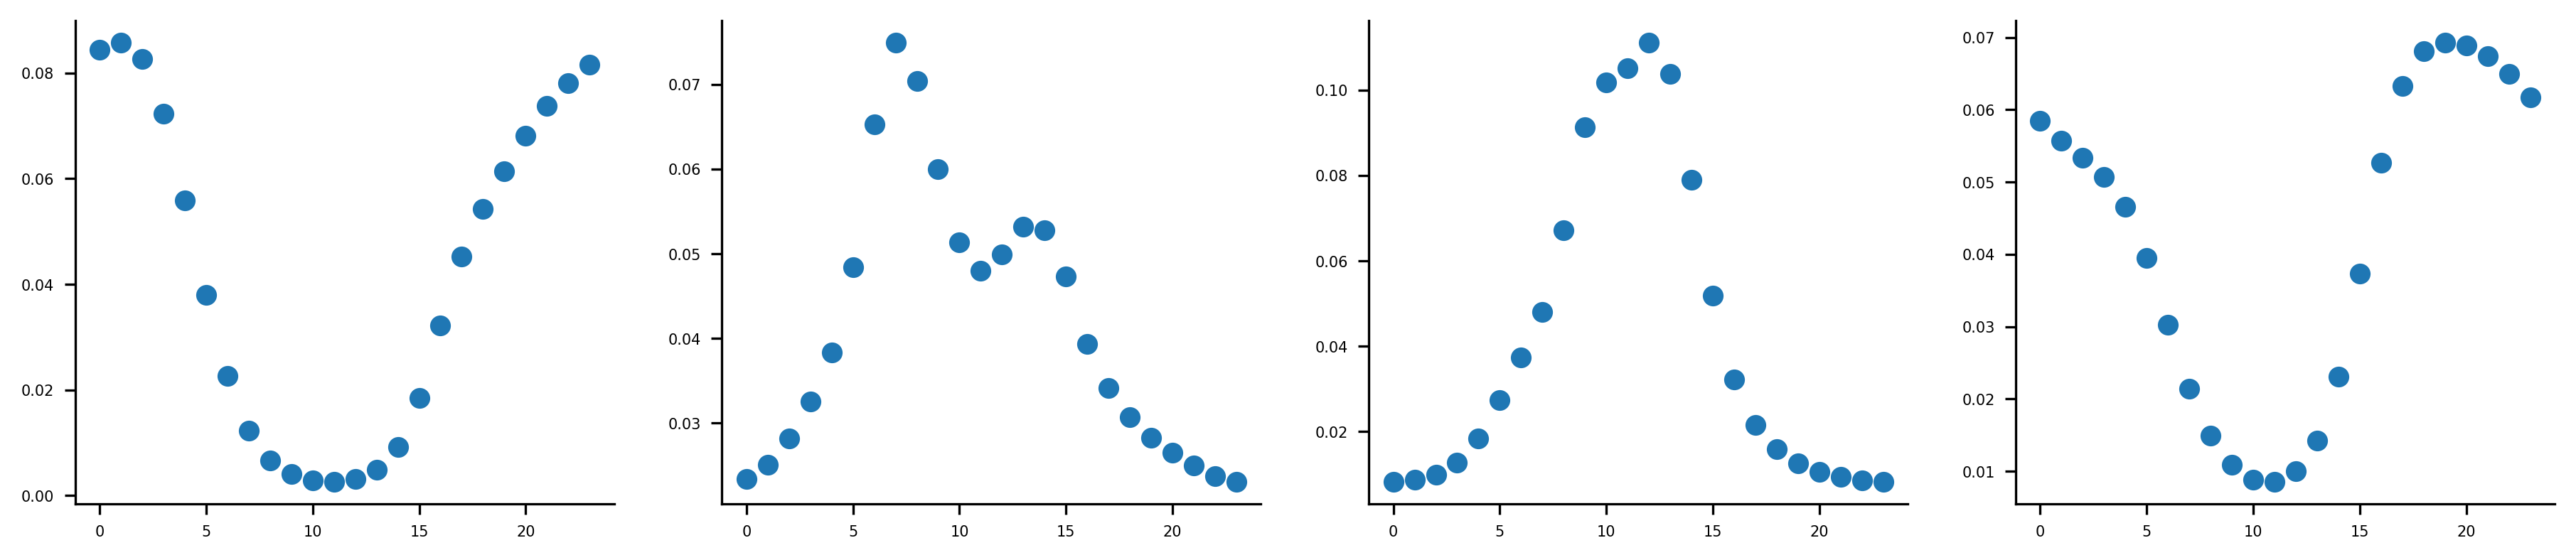

In [88]:
cluster = 2
for description in descriptions:
    
    print(description)
    
    # ** load the cell posterior **
    import torch
    from tempo import cell_posterior
    posterior_path = '%s/tempo_results/0/cell_phase_estimation/cell_posterior.tsv' % cluster_description_folder_out_dict[cluster][description]
    posterior_df = pd.read_table(posterior_path,sep='\t',index_col='barcode')
    posterior_obj = cell_posterior.ThetaPosteriorDist(torch.Tensor(np.array(posterior_df)))

    # ** get cluster condition adata **
    cluster_adata = adata[adata.obs['cluster'] == cluster]
    cluster_condition_adata = cluster_adata[(cluster_adata.obs['description'] == description)]


    # ** for each time point, get the pseudobulk posterior **
    unique_zt = [0,6,12,18]
    fig,axs = plt.subplots(figsize=(15,3), nrows=1,ncols=4,dpi=300)
    for zt_index,zt in enumerate(unique_zt):
        zt_cell_barcodes = list(set(cluster_condition_adata.obs[cluster_condition_adata.obs['zt'] == zt].index).intersection(set(posterior_df.index)))
        pseudobulk_density = np.array(np.sum(posterior_df.loc[zt_cell_barcodes],axis=0))
        pseudobulk_density = pseudobulk_density / np.sum(pseudobulk_density)
        axs[zt_index].scatter((posterior_obj.phase_grid.numpy() / np.pi) * 12.0, pseudobulk_density)
    sns.despine()
    plt.show()



male misaligned bmal1-control


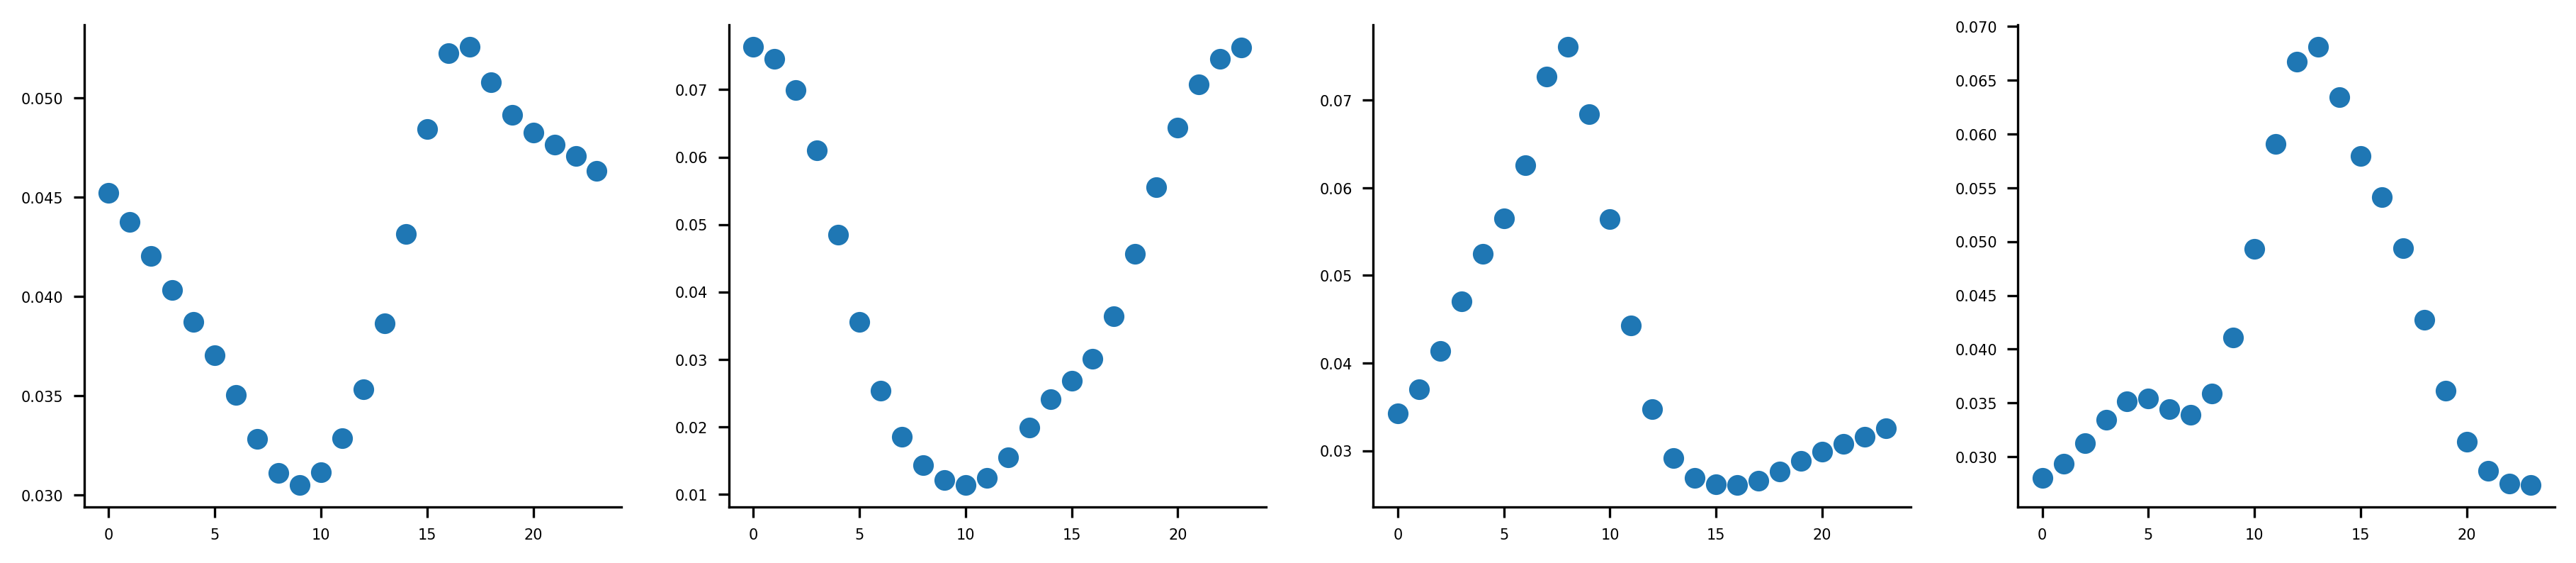

female misaligned bmal1-control


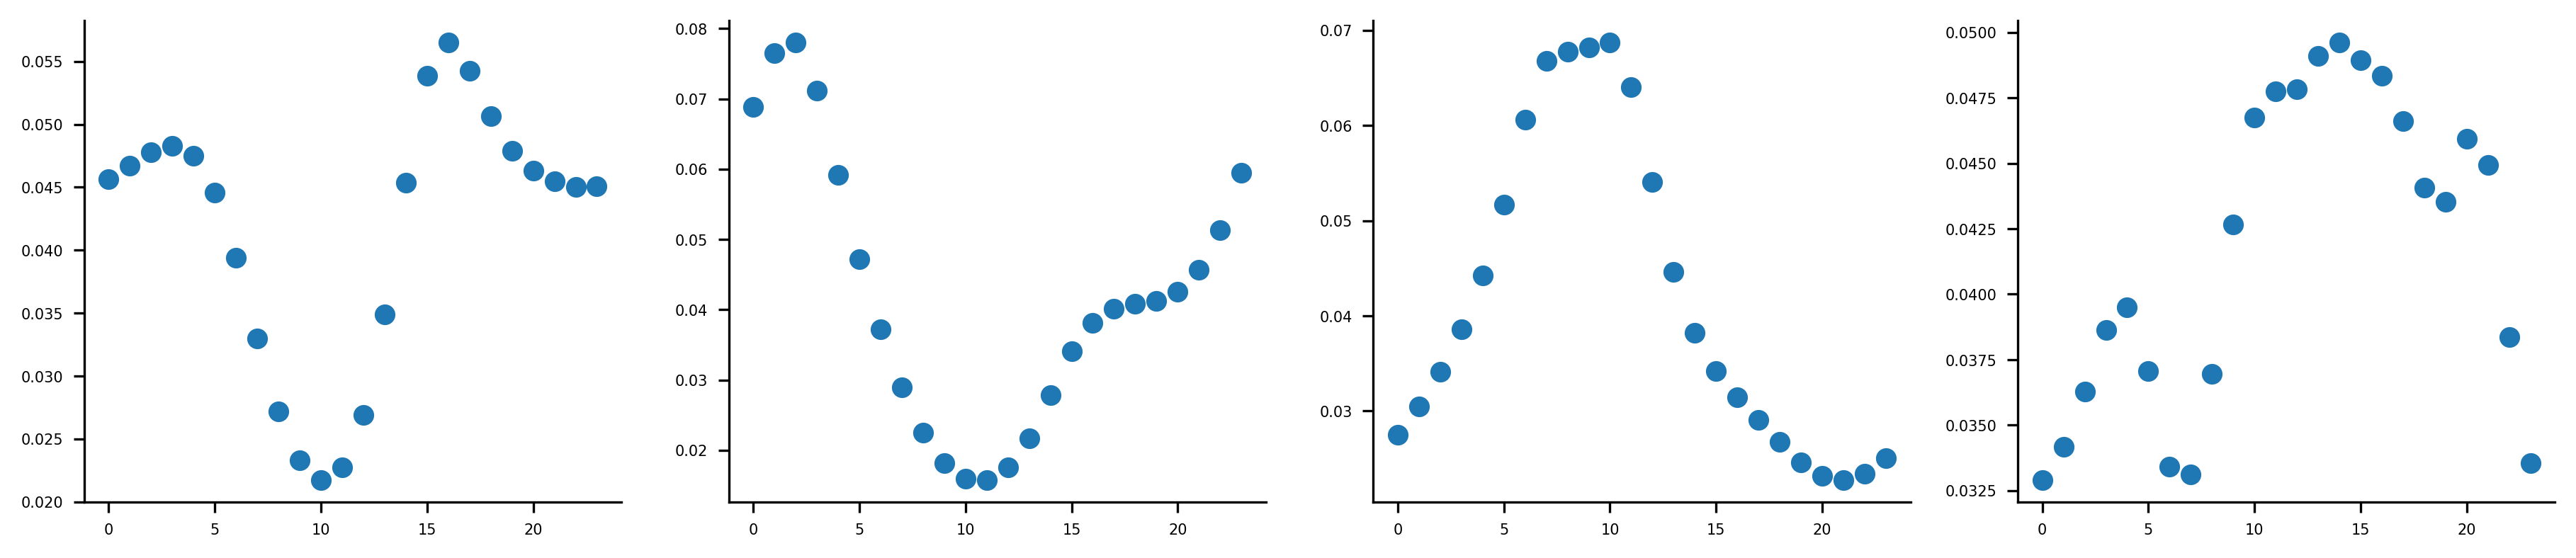

male aligned bmal1-control


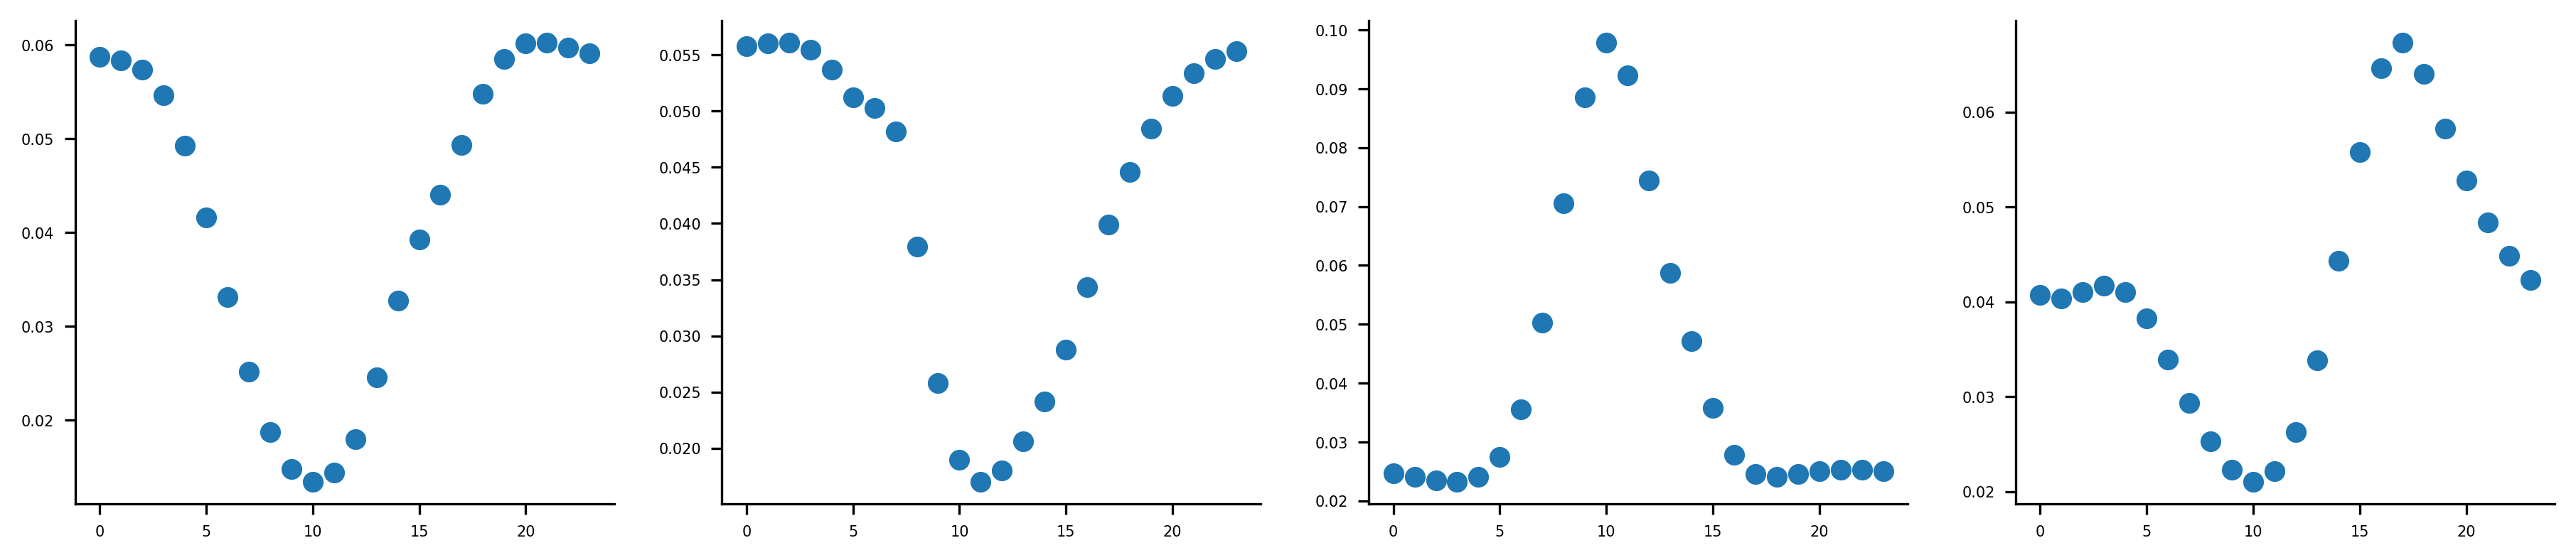

female aligned bmal1-control


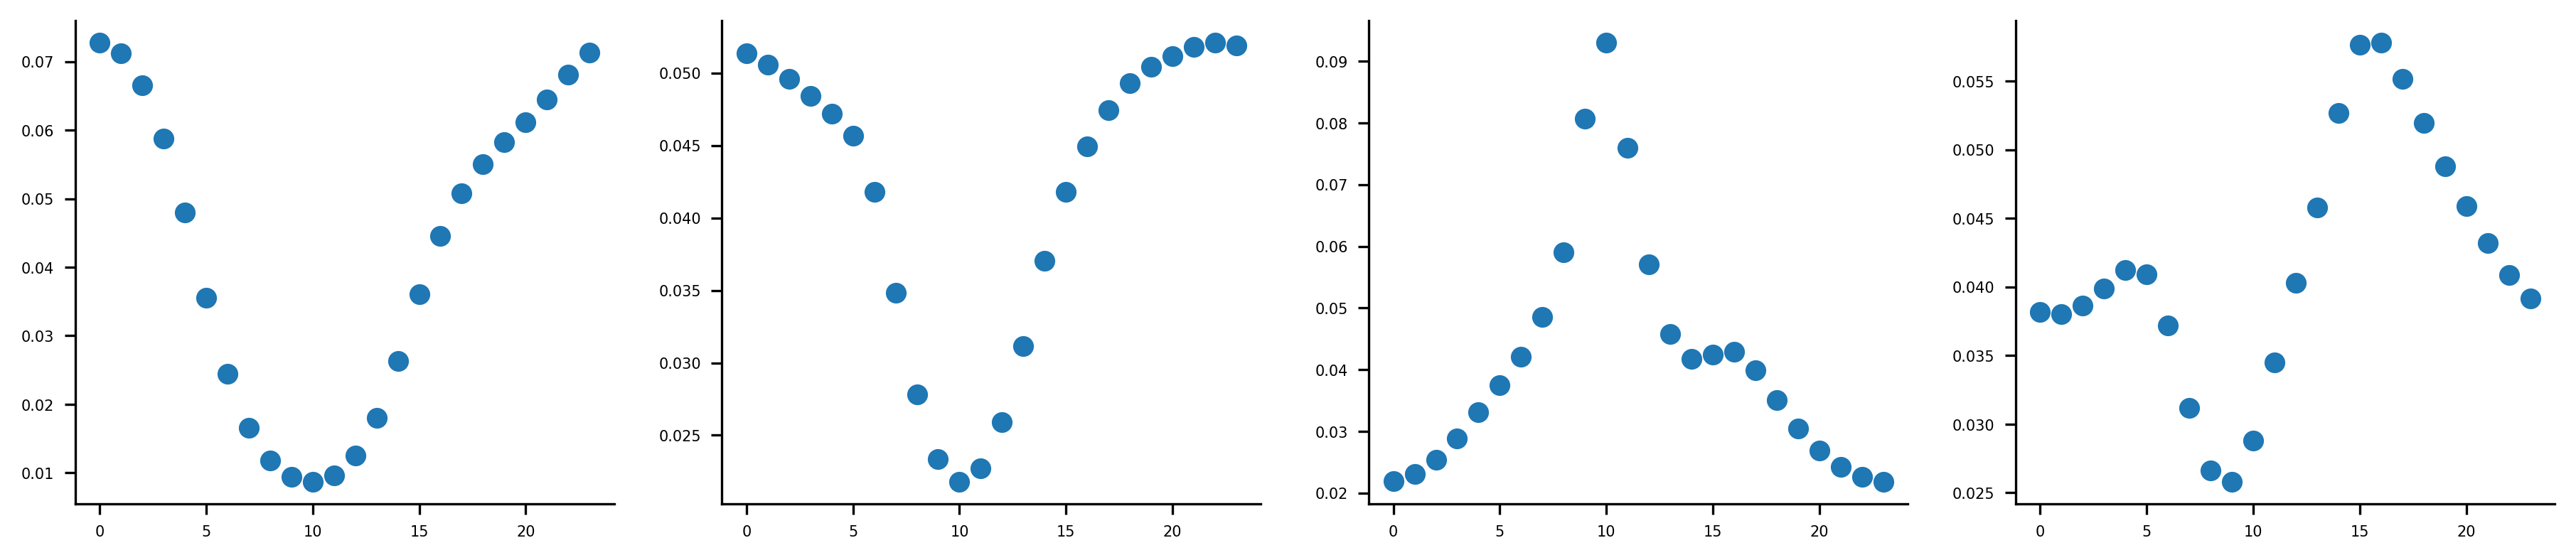

In [86]:
cluster = 3
for description in descriptions:
    
    print(description)
    
    # ** load the cell posterior **
    import torch
    from tempo import cell_posterior
    posterior_path = '%s/tempo_results/0/cell_phase_estimation/cell_posterior.tsv' % cluster_description_folder_out_dict[cluster][description]
    posterior_df = pd.read_table(posterior_path,sep='\t',index_col='barcode')
    posterior_obj = cell_posterior.ThetaPosteriorDist(torch.Tensor(np.array(posterior_df)))

    # ** get cluster condition adata **
    cluster_adata = adata[adata.obs['cluster'] == cluster]
    cluster_condition_adata = cluster_adata[(cluster_adata.obs['description'] == description)]


    # ** for each time point, get the pseudobulk posterior **
    unique_zt = [0,6,12,18]
    fig,axs = plt.subplots(figsize=(15,3), nrows=1,ncols=4,dpi=300)
    for zt_index,zt in enumerate(unique_zt):
        zt_cell_barcodes = list(set(cluster_condition_adata.obs[cluster_condition_adata.obs['zt'] == zt].index).intersection(set(posterior_df.index)))
        pseudobulk_density = np.array(np.sum(posterior_df.loc[zt_cell_barcodes],axis=0))
        pseudobulk_density = pseudobulk_density / np.sum(pseudobulk_density)
        axs[zt_index].scatter((posterior_obj.phase_grid.numpy() / np.pi) * 12.0, pseudobulk_density)
    sns.despine()
    plt.show()



In [45]:
# ** get cells that are 10 times as likely to be from ZT6 AS FROM ZT 18 **
zt = 0
zt_cell_barcodes = cluster_condition_adata.obs[cluster_condition_adata.obs['zt'] == zt].index
zt_posterior_df = posterior_df.loc[zt_cell_barcodes]
zt_posterior_obj = cell_posterior.ThetaPosteriorDist(torch.Tensor(np.array(zt_posterior_df)))
prob_a = zt_posterior_obj.log_prob(torch.Tensor(np.array([(6 / 24) * 2 * np.pi])))
prob_b = zt_posterior_obj.log_prob(torch.Tensor(np.array([(18 / 24) * 2 * np.pi])))


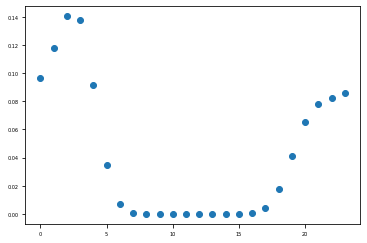

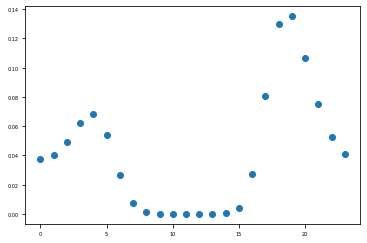

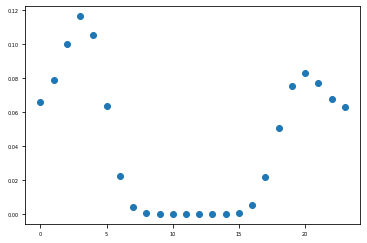

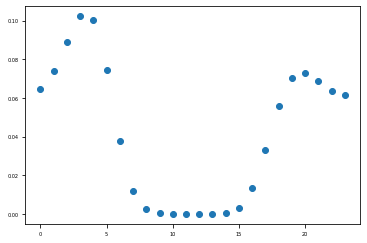

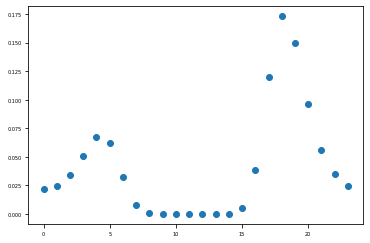

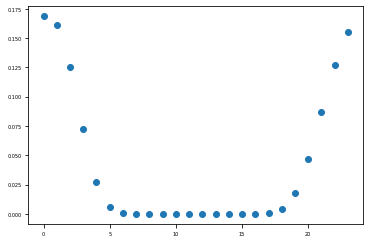

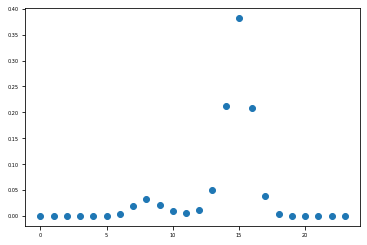

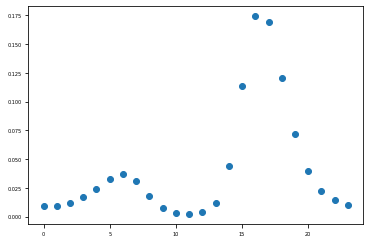

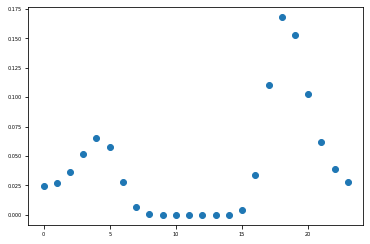

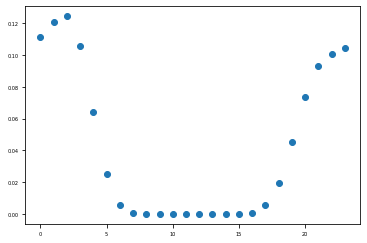

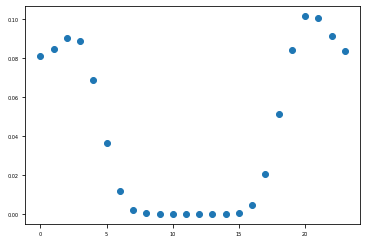

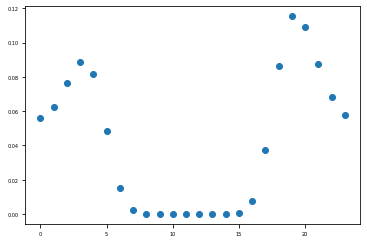

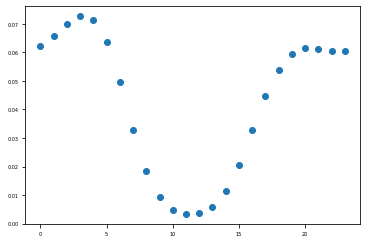

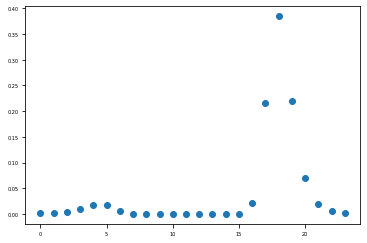

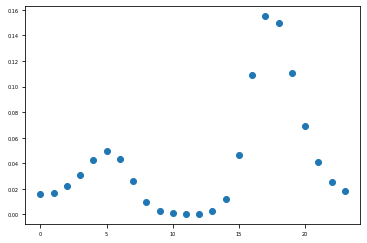

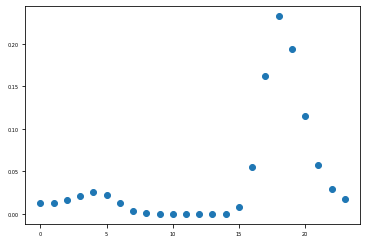

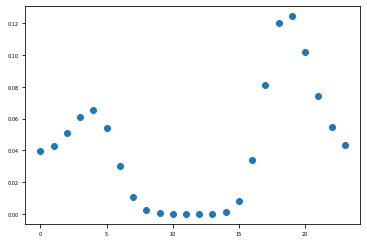

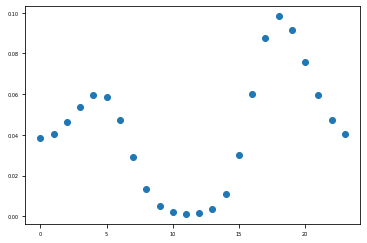

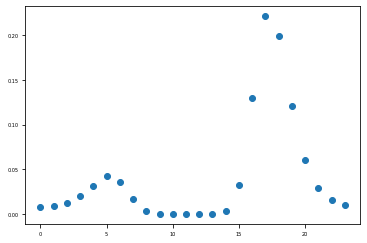

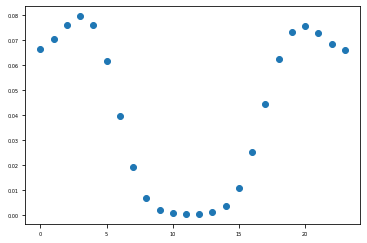

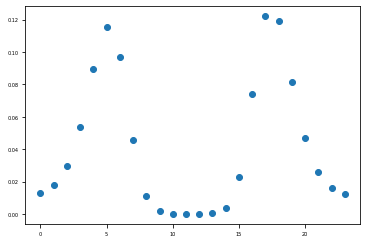

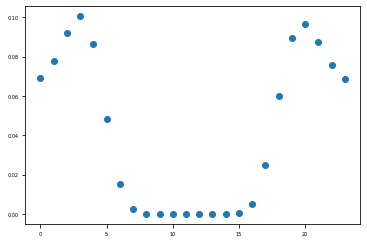

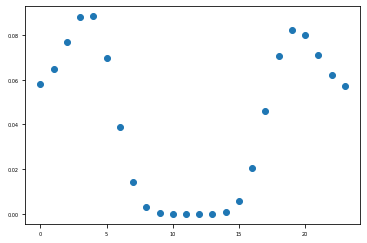

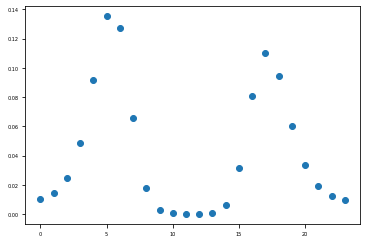

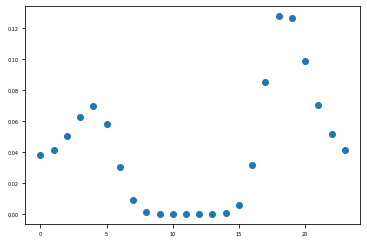

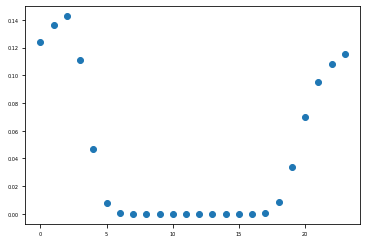

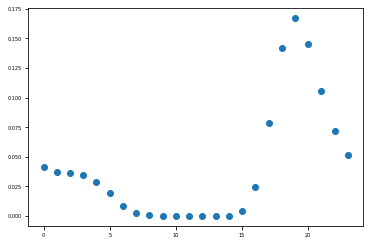

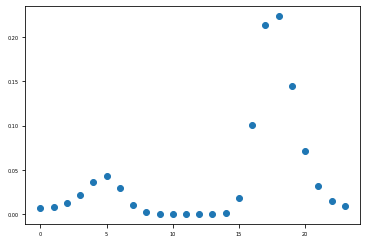

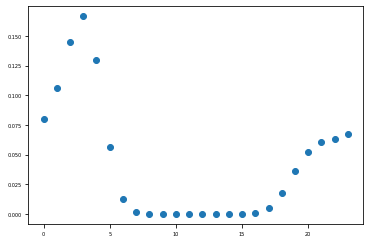

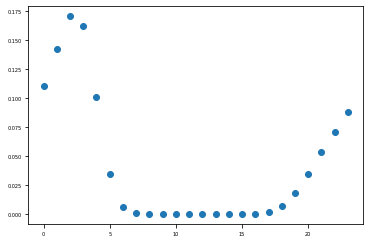

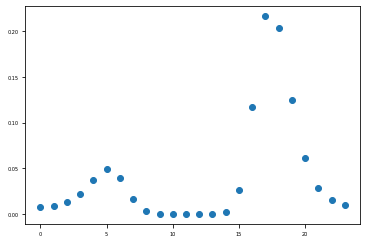

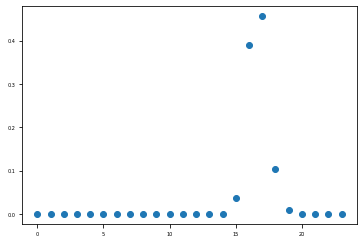

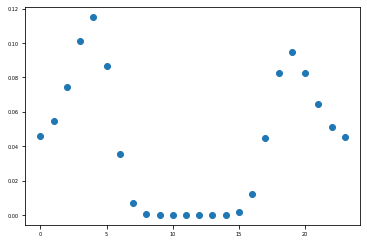

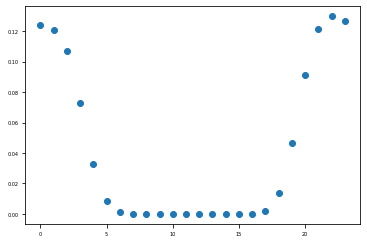

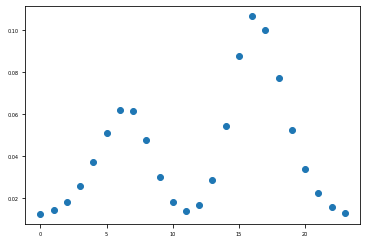

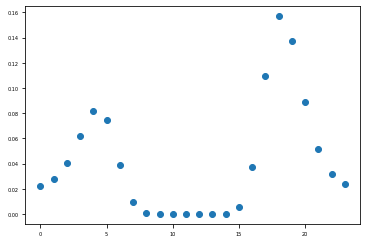

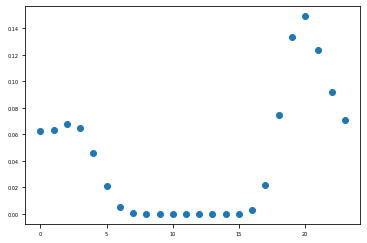

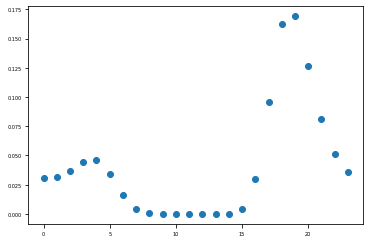

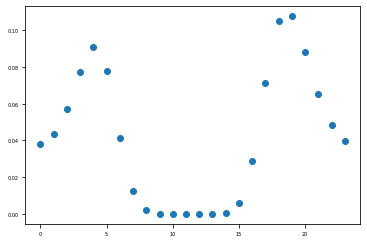

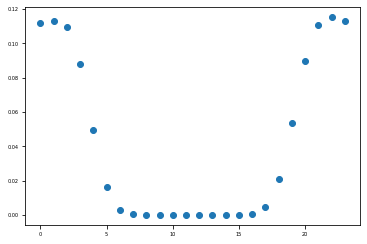

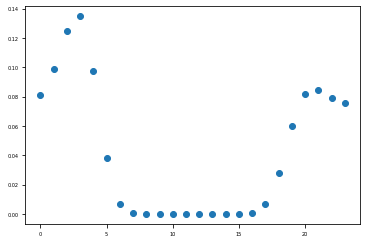

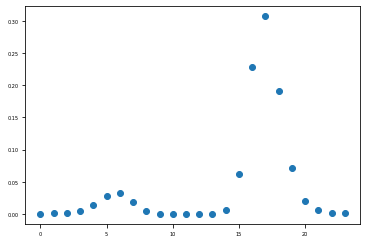

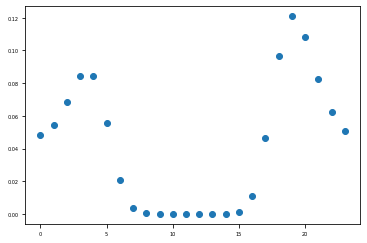

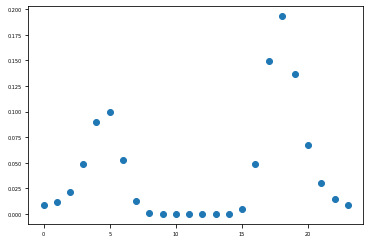

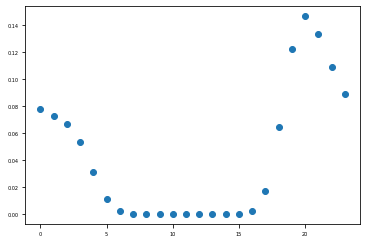

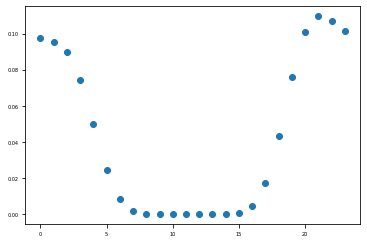

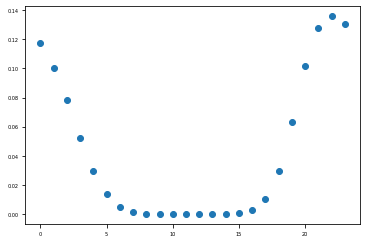

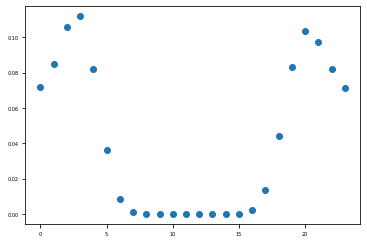

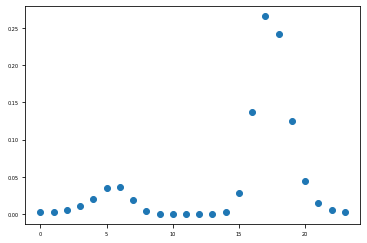

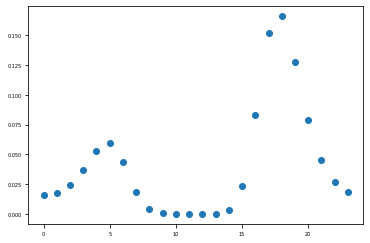

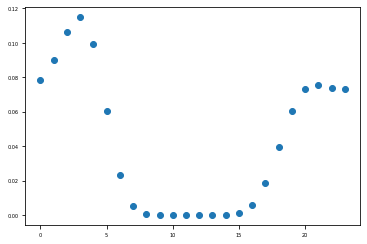

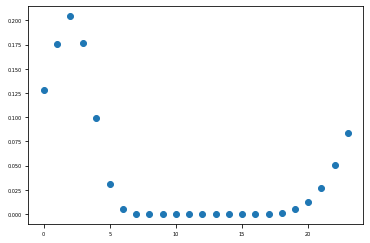

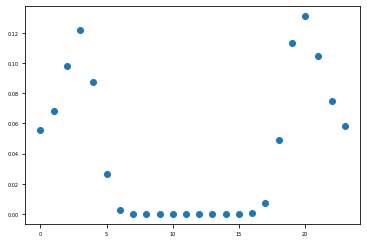

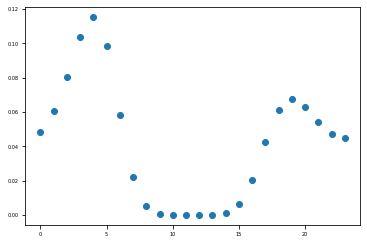

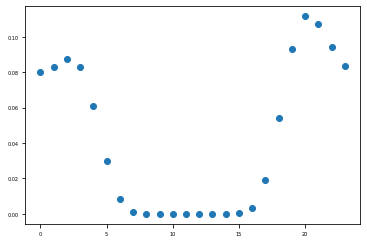

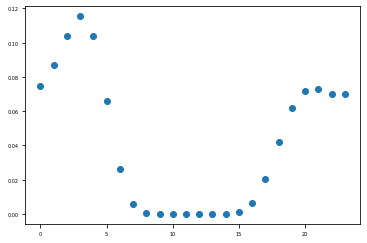

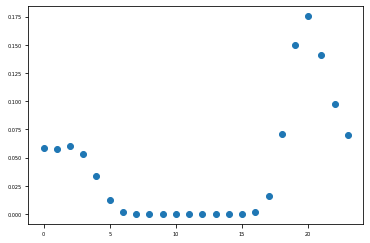

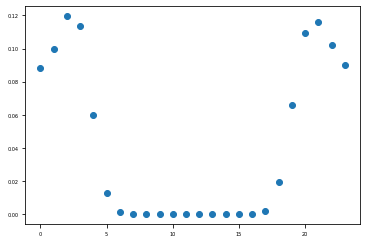

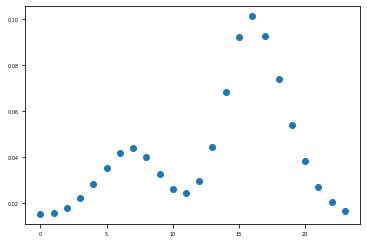

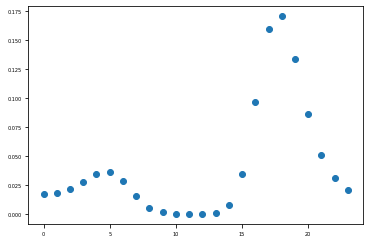

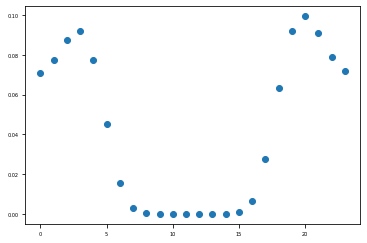

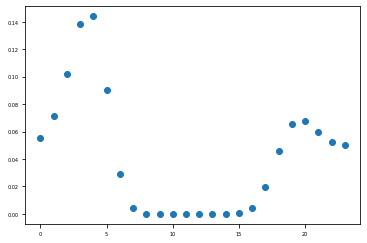

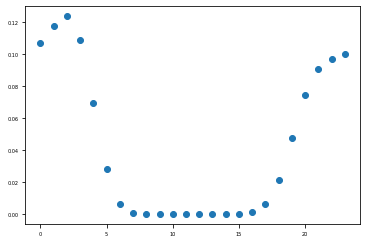

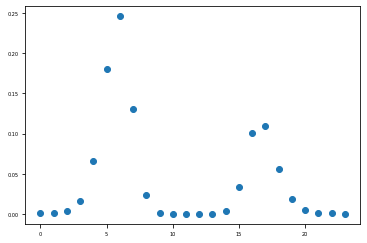

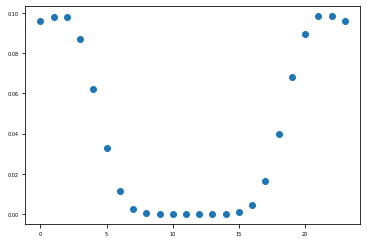

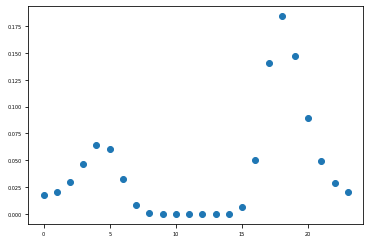

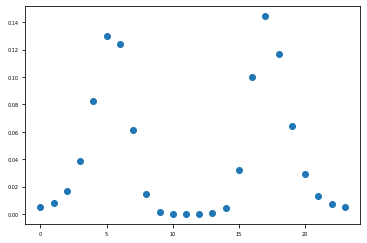

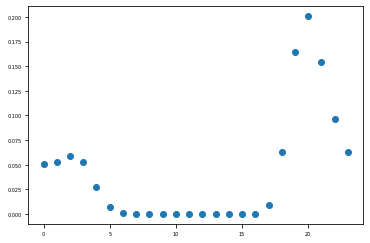

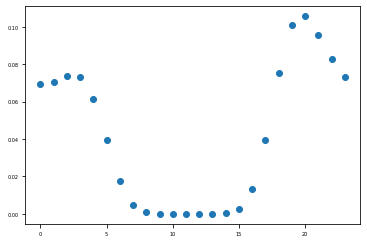

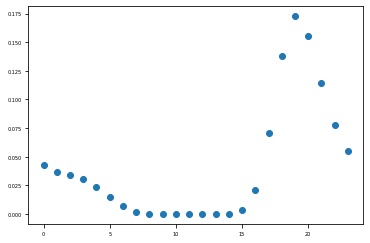

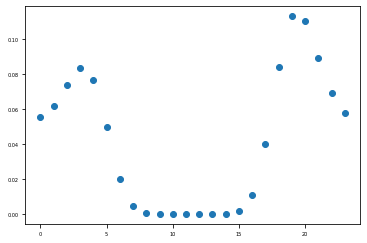

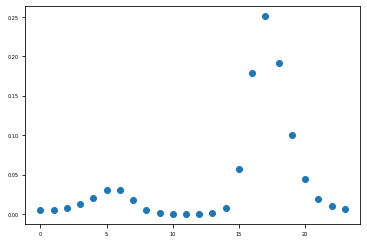

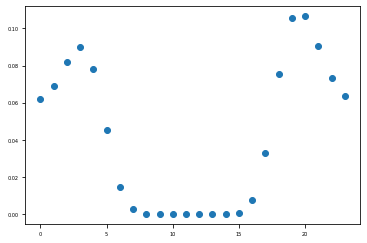

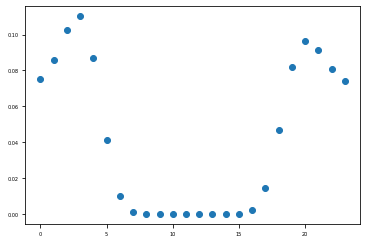

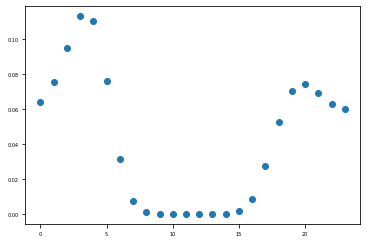

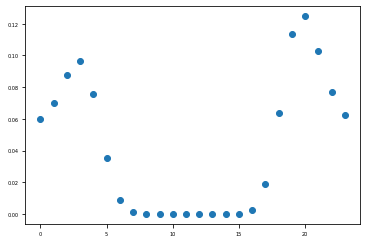

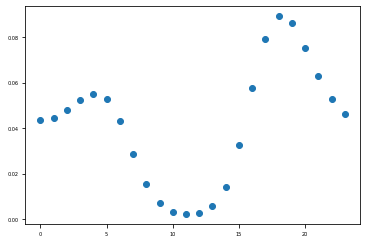

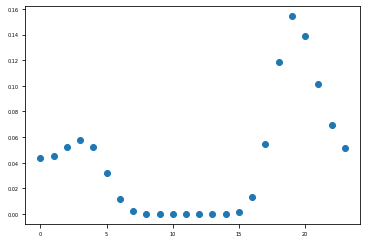

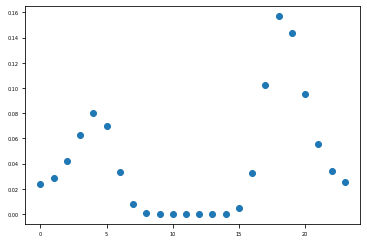

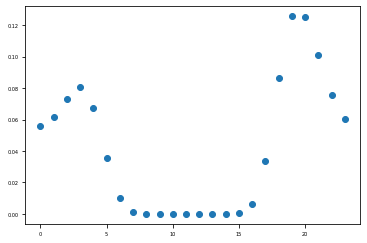

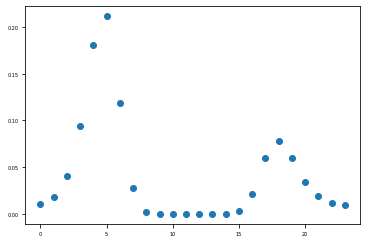

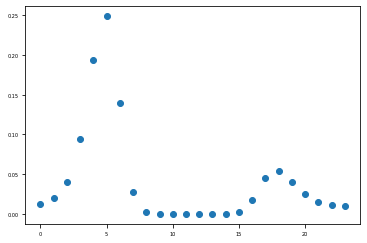

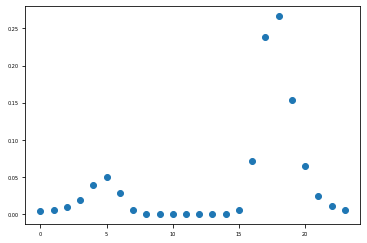

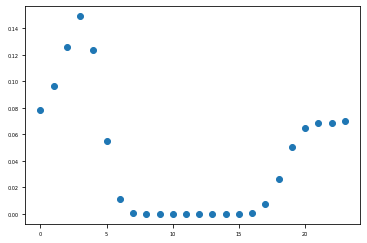

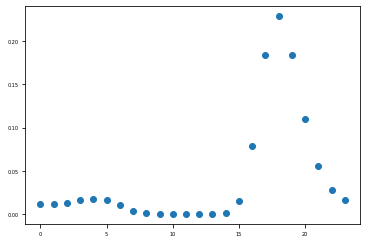

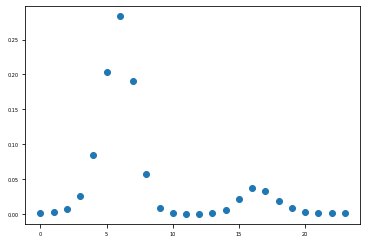

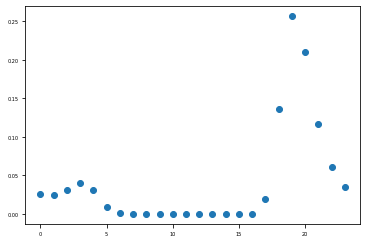

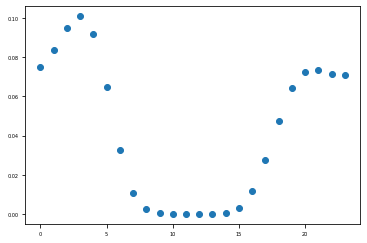

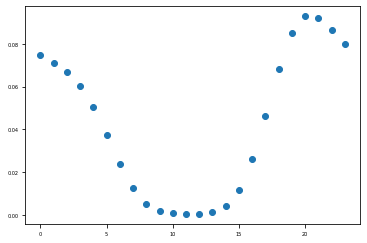

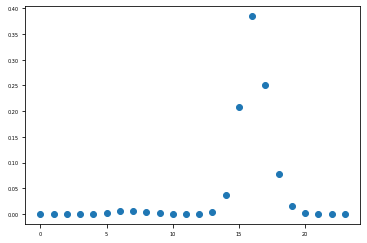

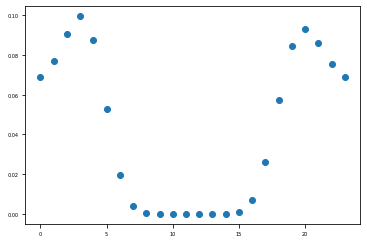

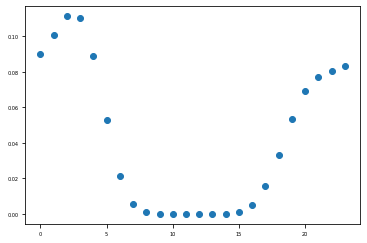

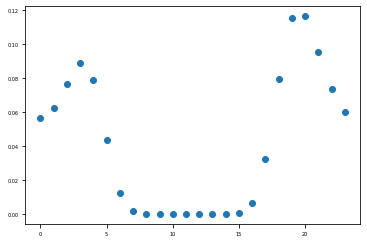

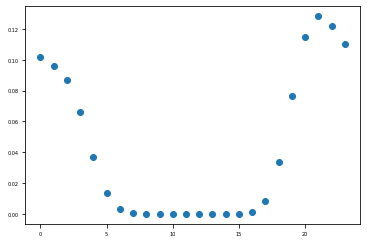

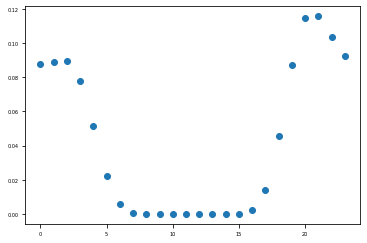

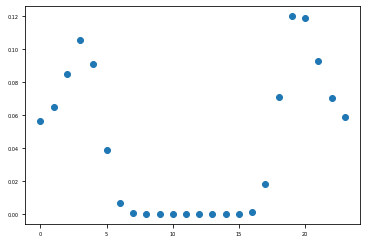

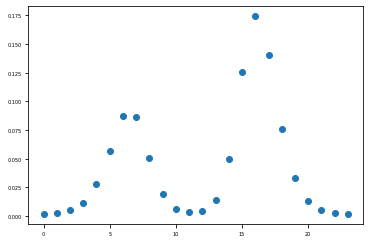

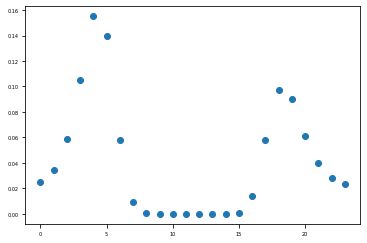

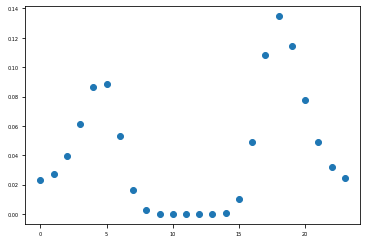

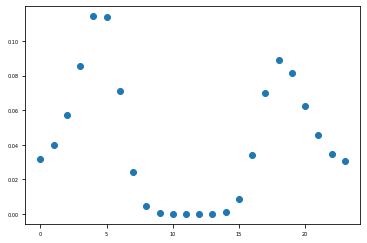

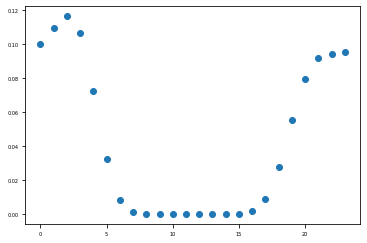

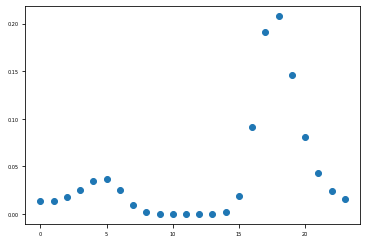

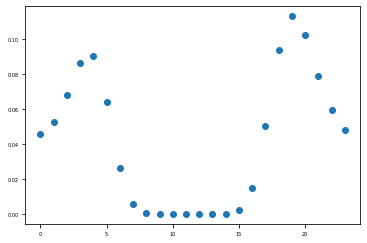

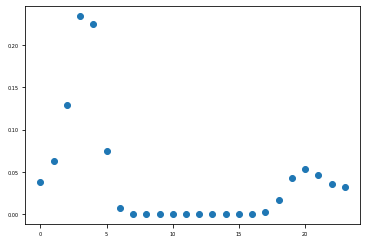

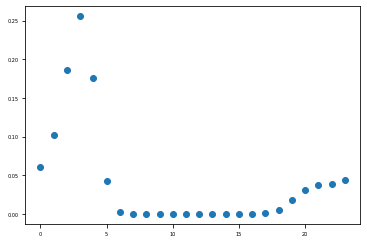

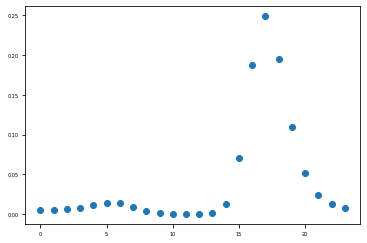

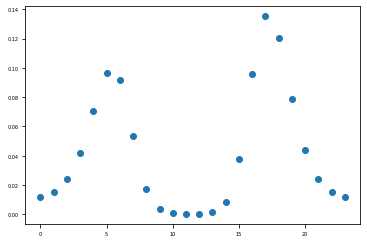

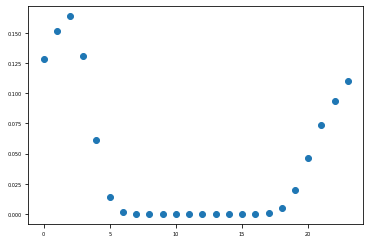

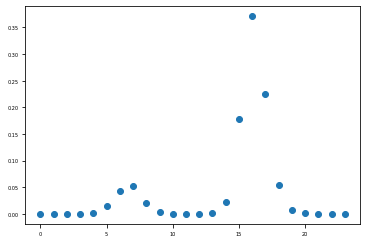

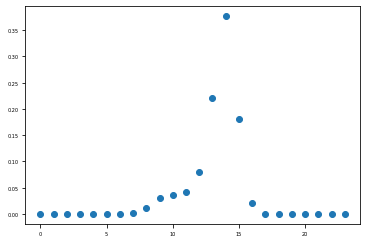

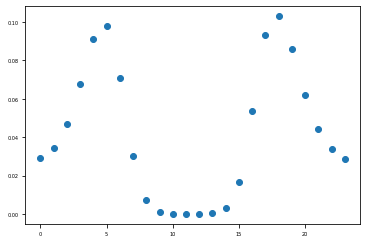

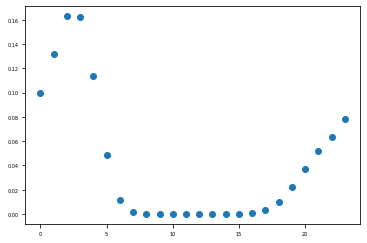

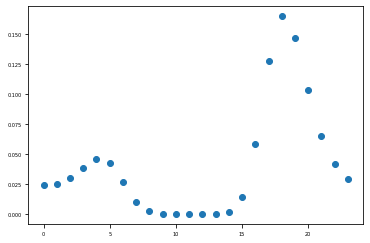

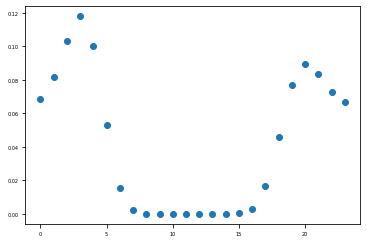

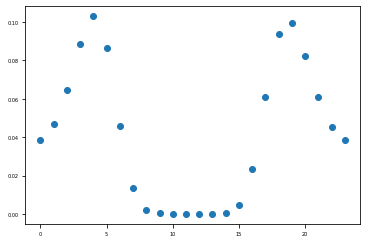

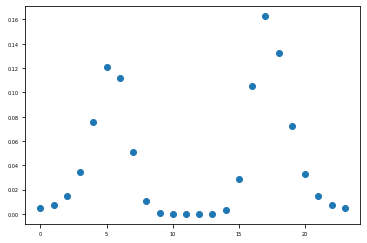

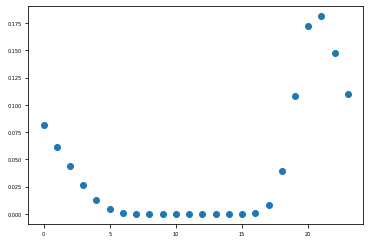

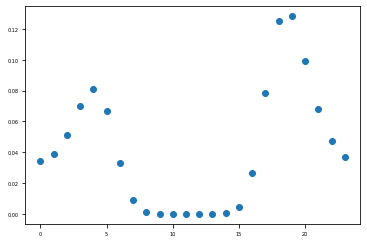

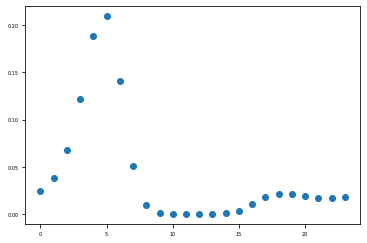

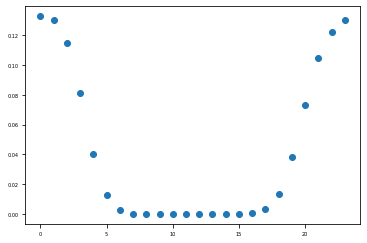

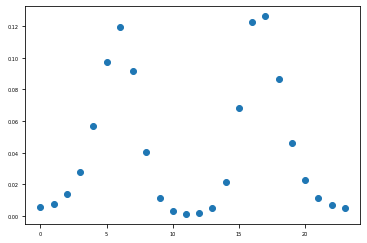

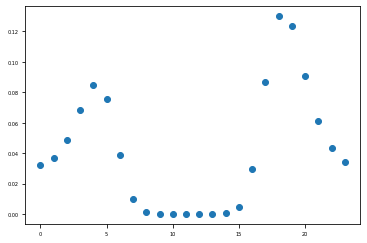

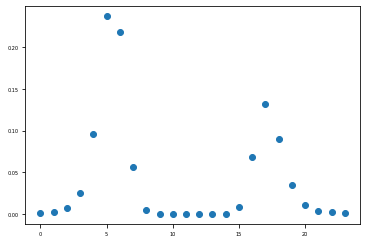

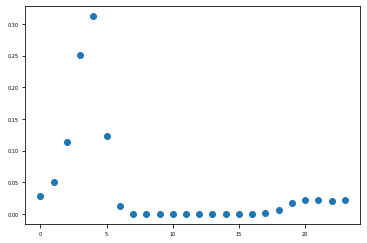

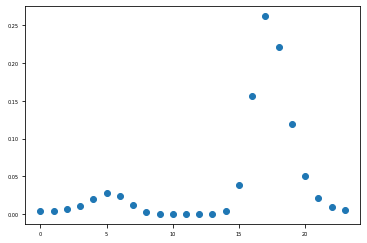

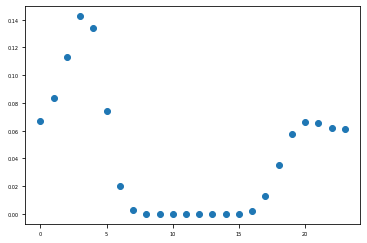

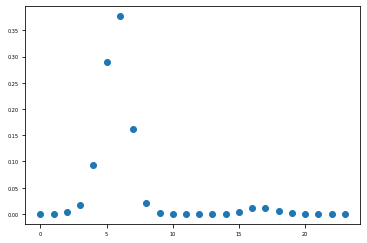

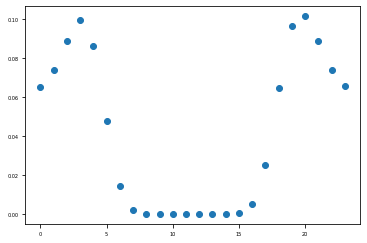

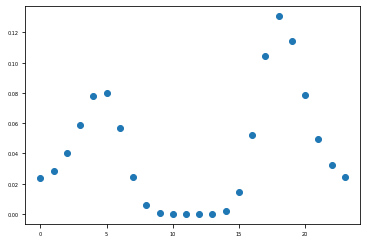

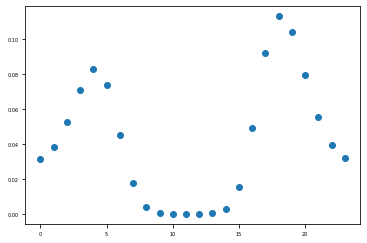

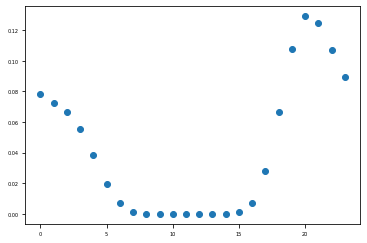

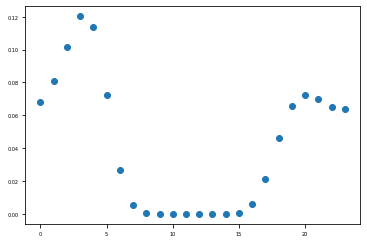

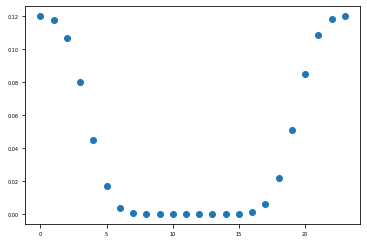

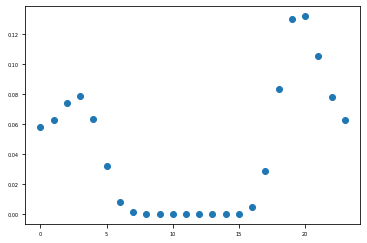

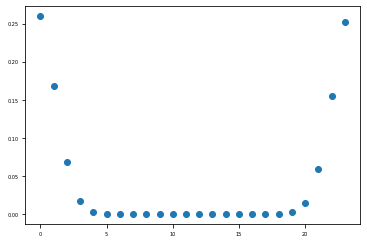

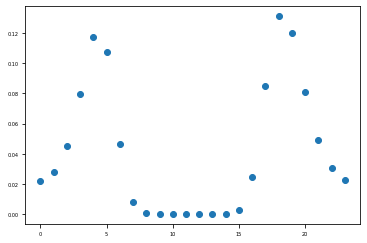

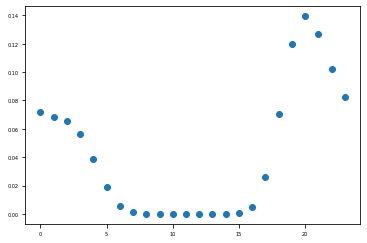

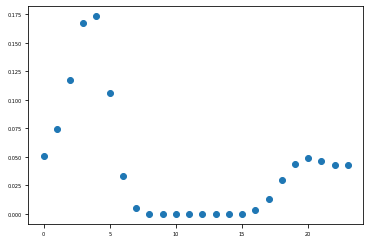

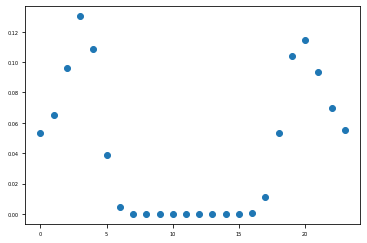

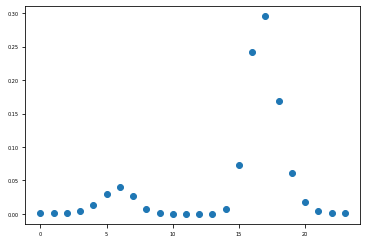

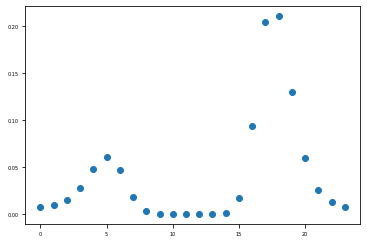

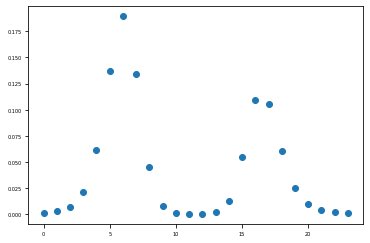

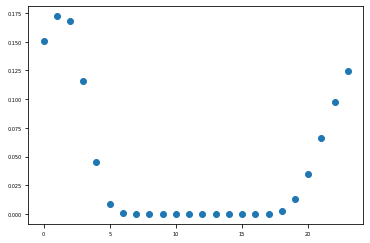

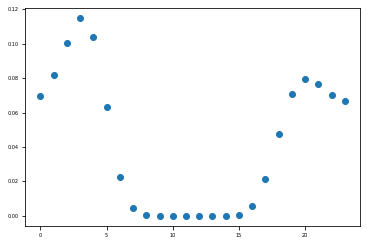

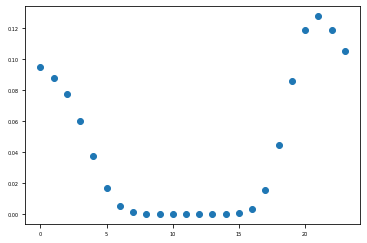

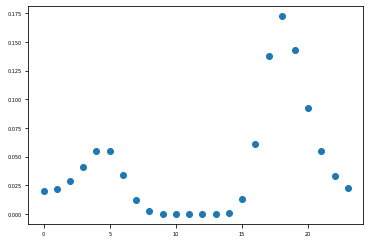

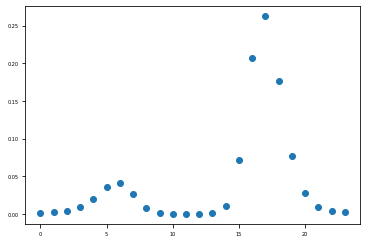

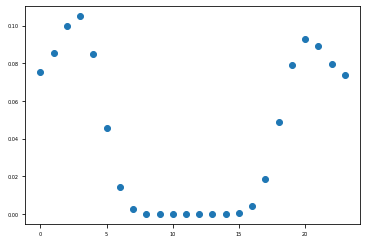

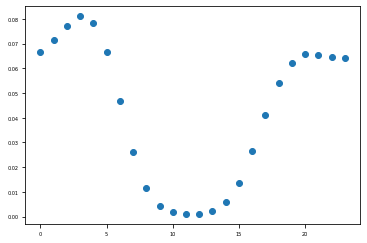

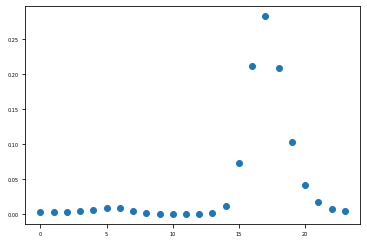

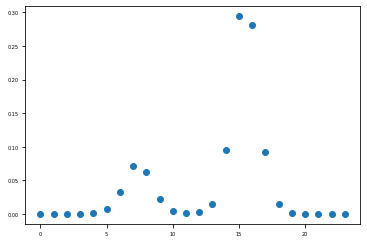

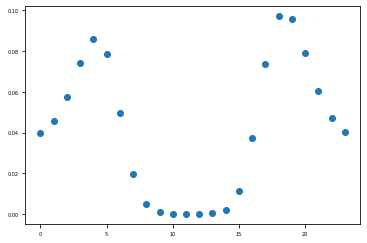

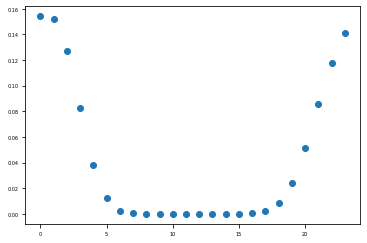

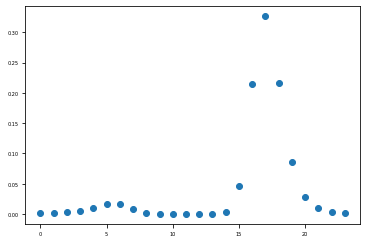

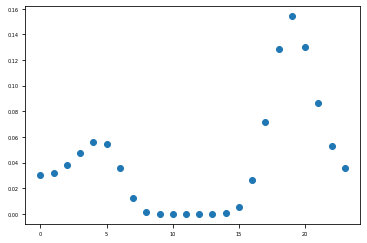

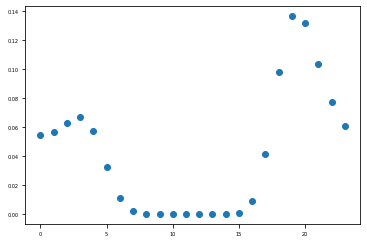

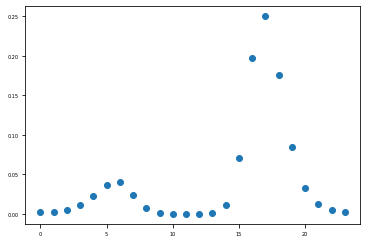

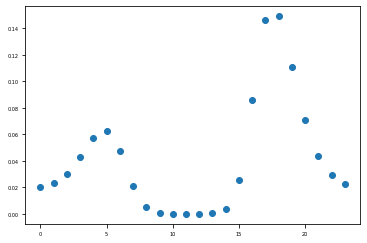

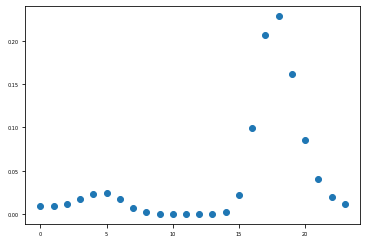

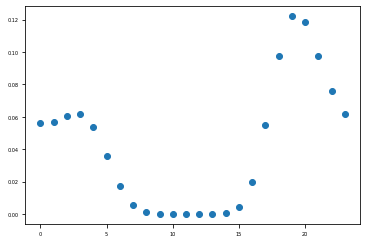

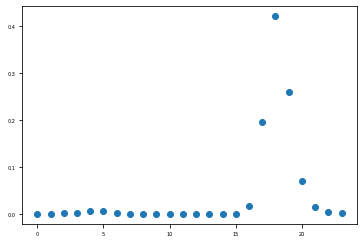

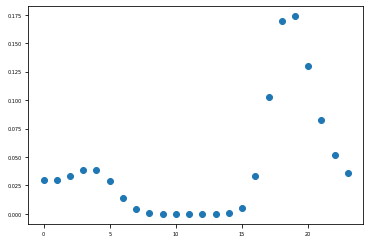

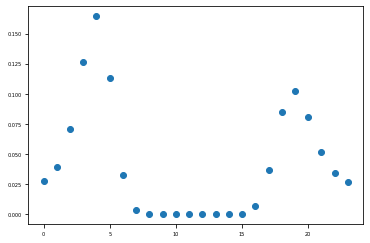

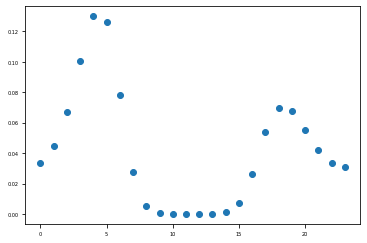

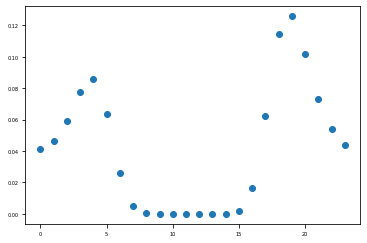

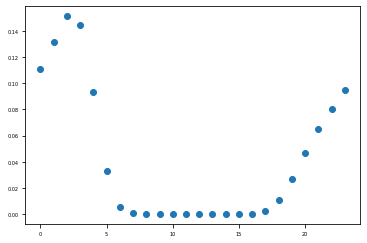

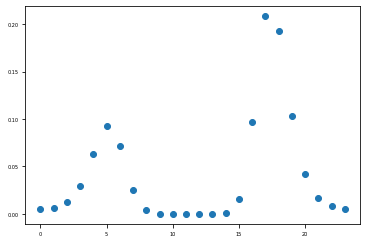

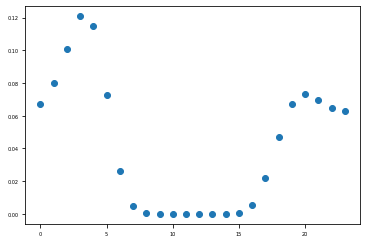

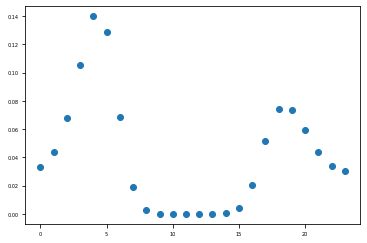

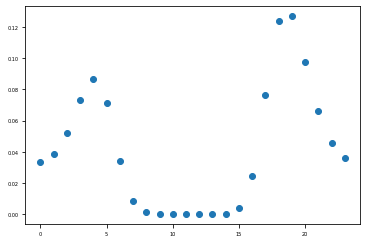

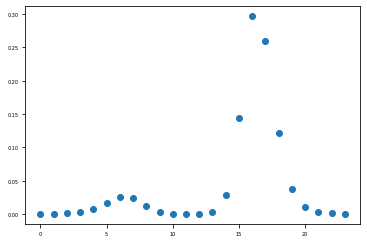

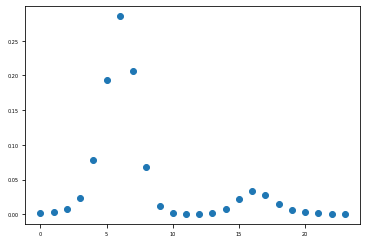

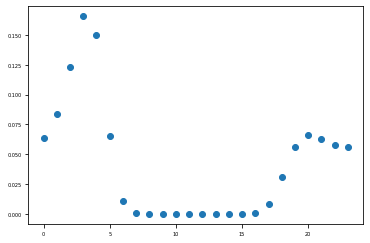

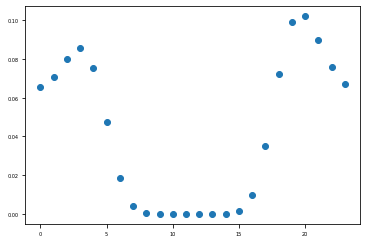

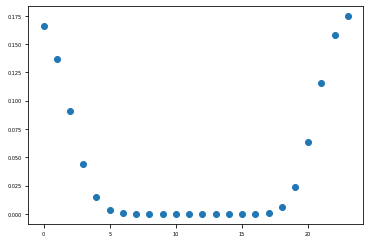

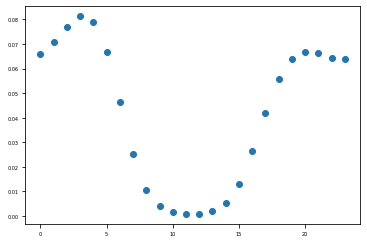

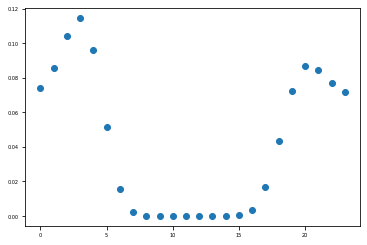

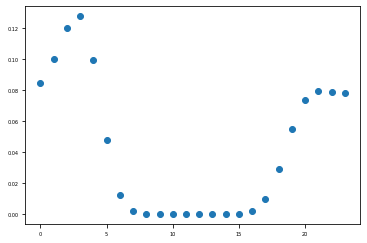

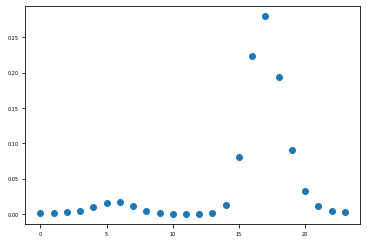

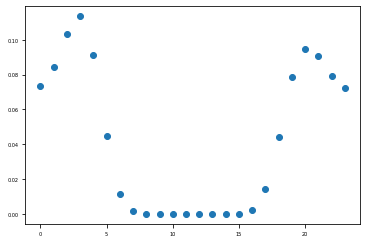

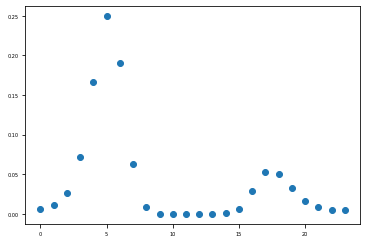

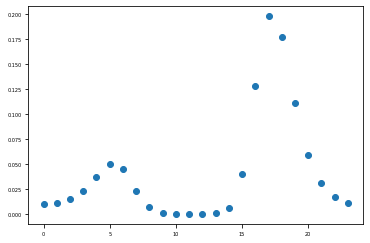

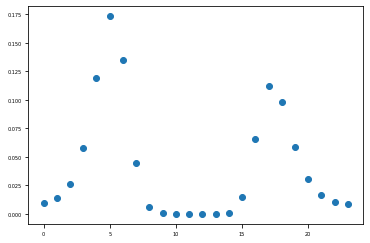

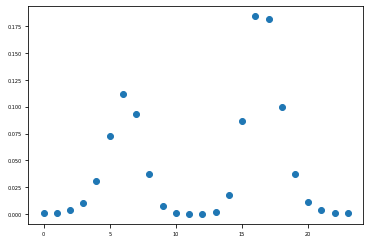

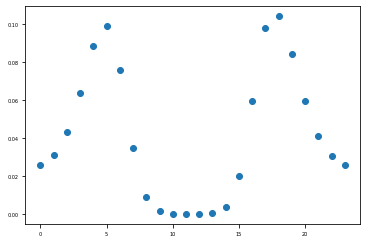

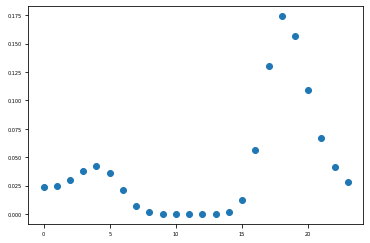

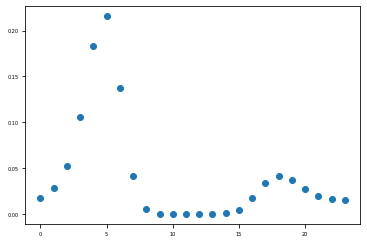

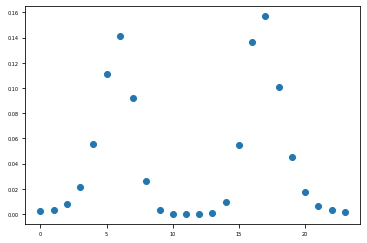

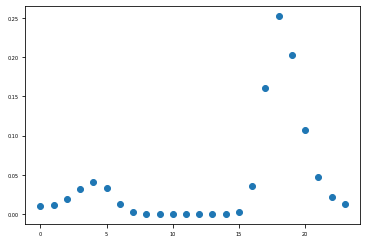

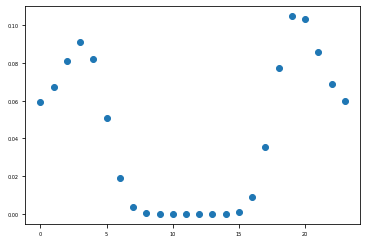

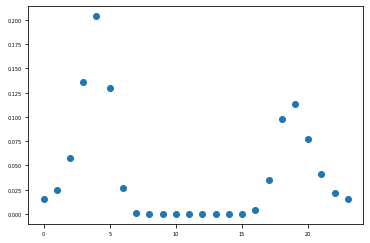

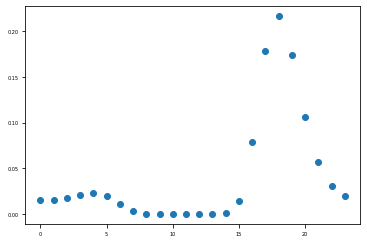

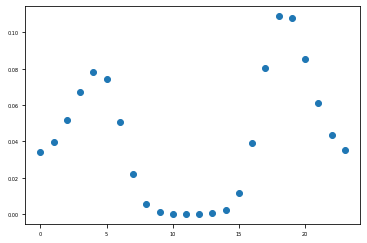

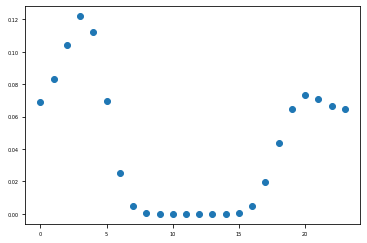

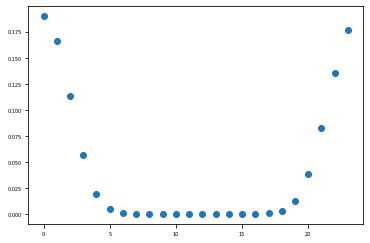

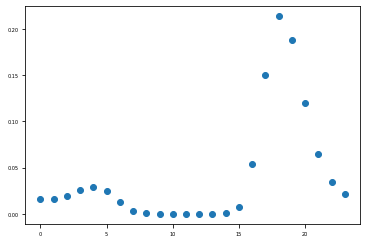

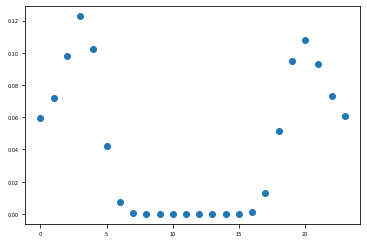

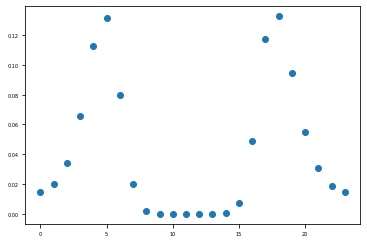

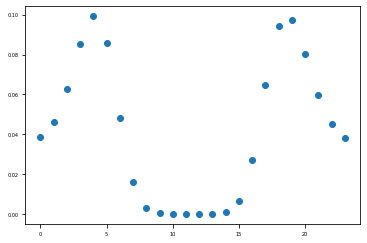

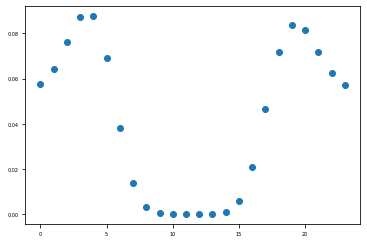

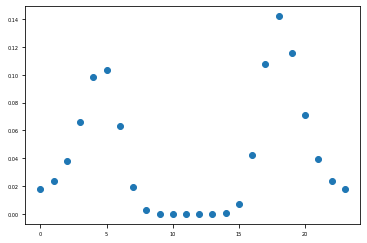

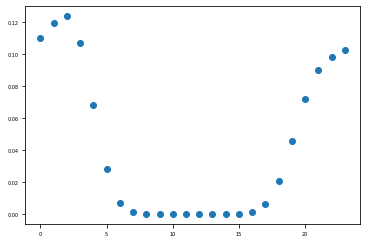

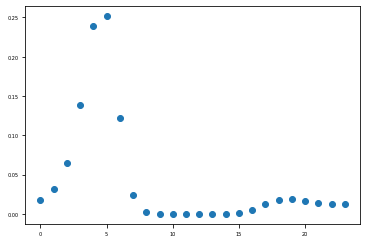

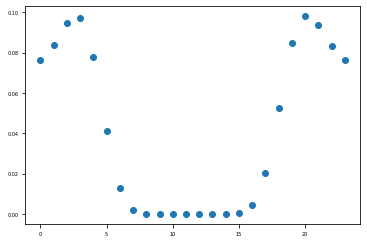

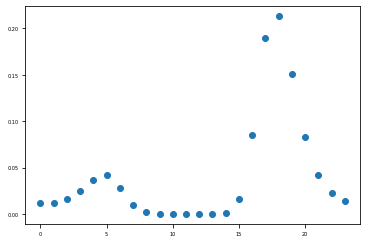

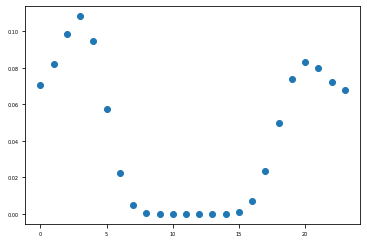

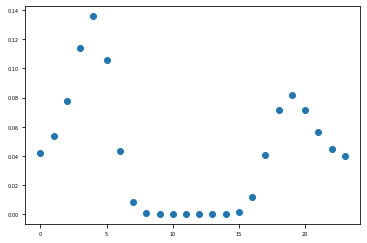

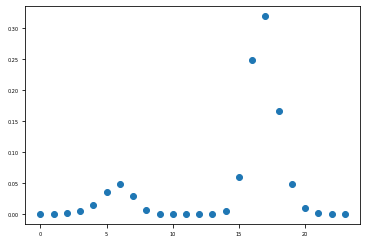

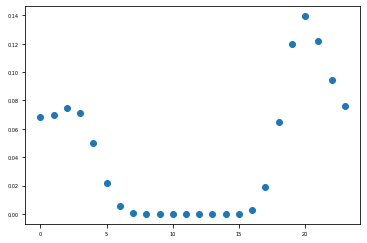

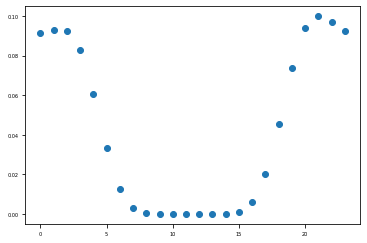

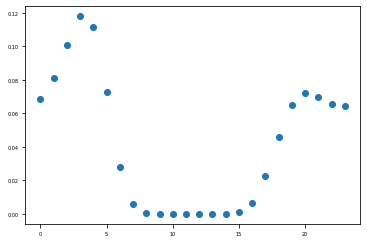

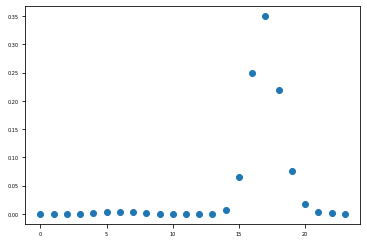

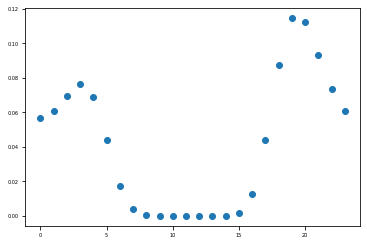

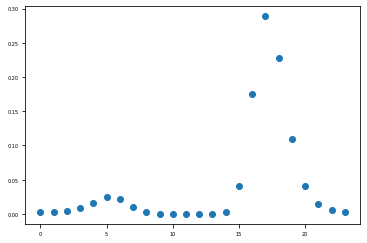

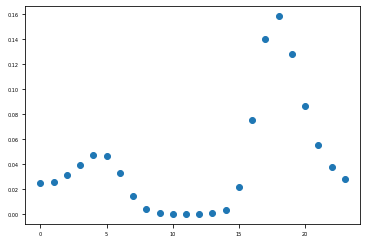

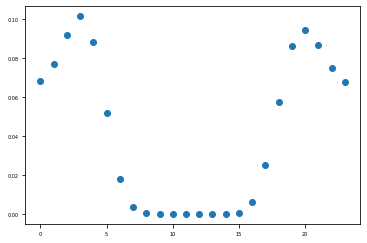

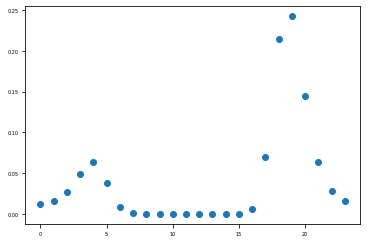

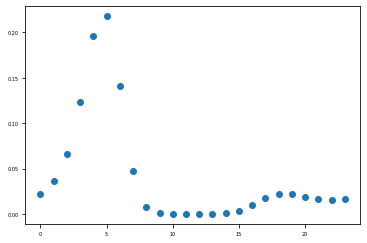

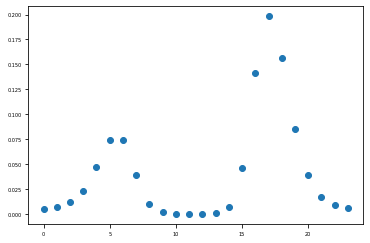

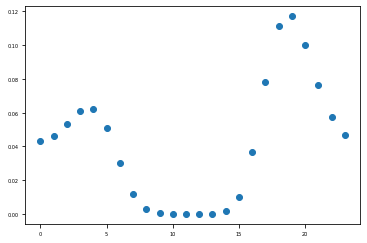

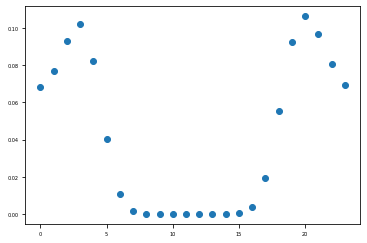

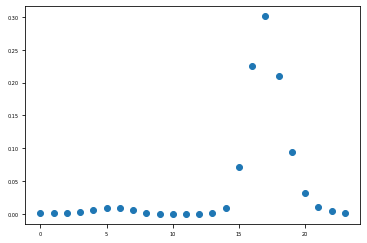

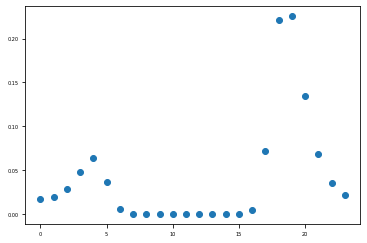

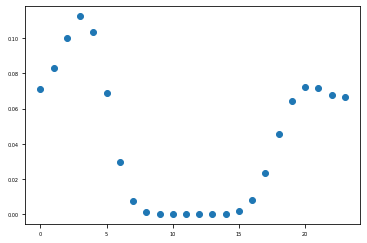

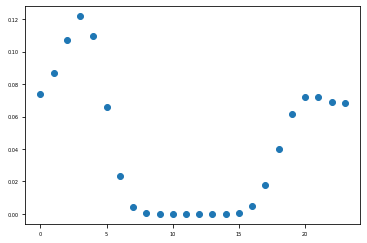

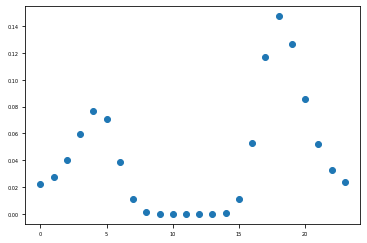

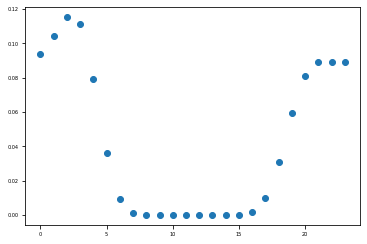

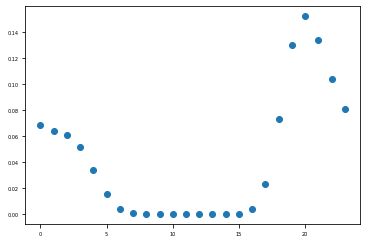

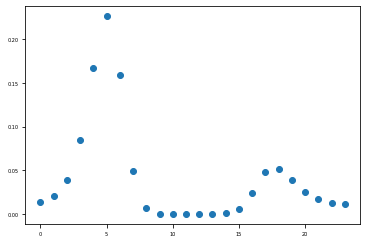

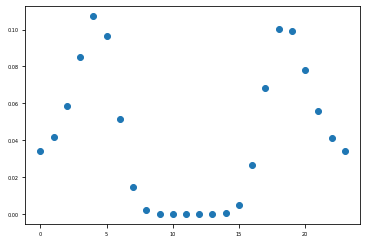

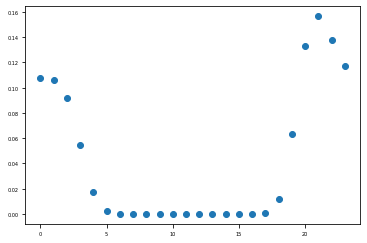

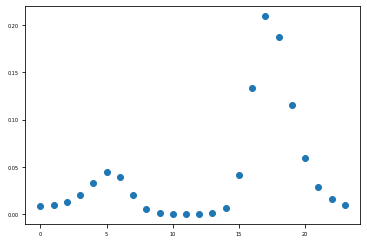

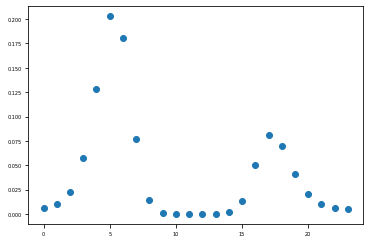

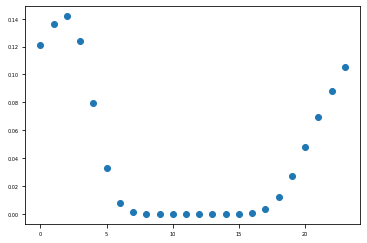

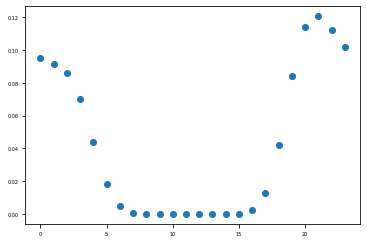

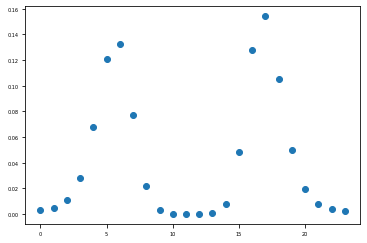

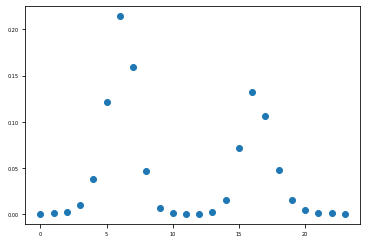

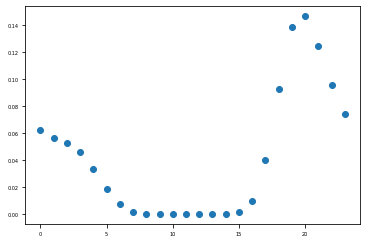

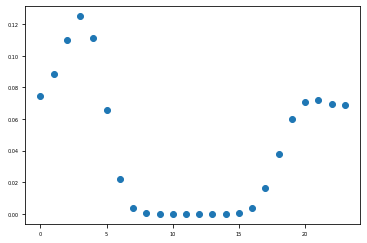

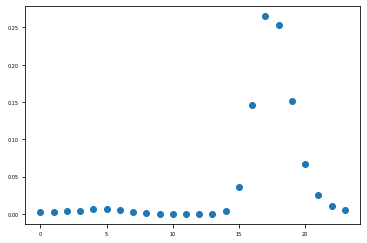

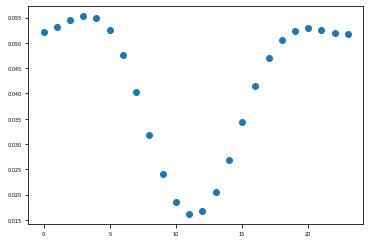

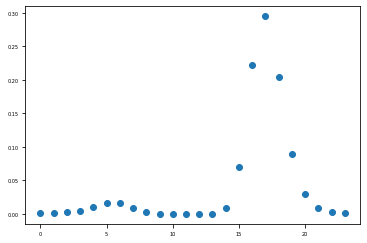

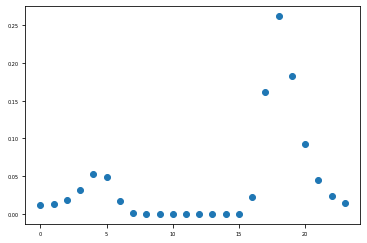

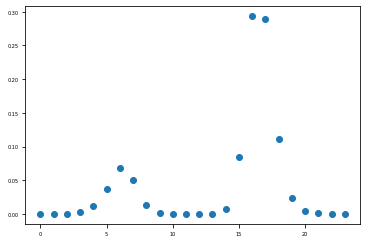

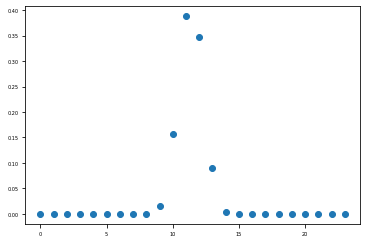

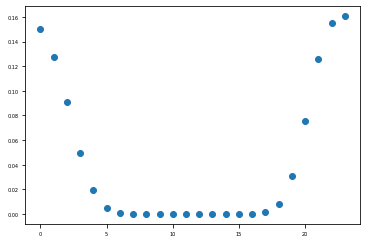

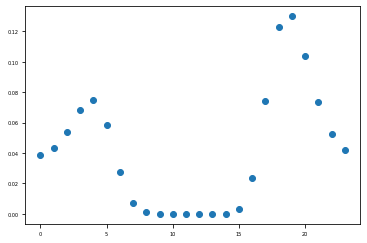

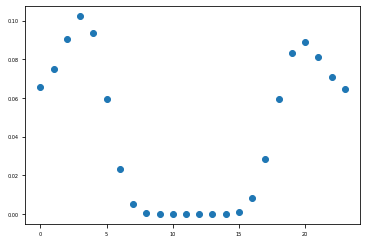

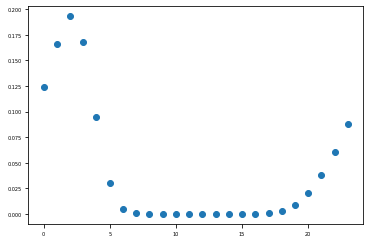

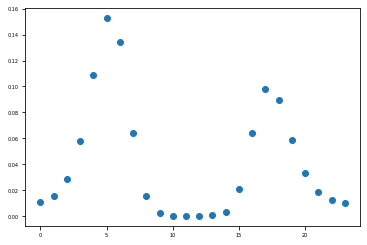

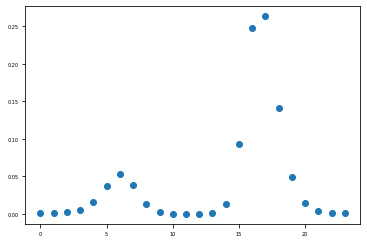

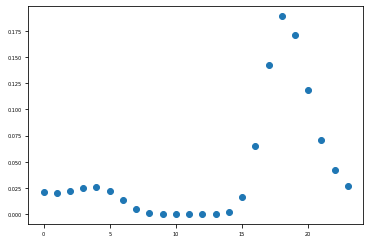

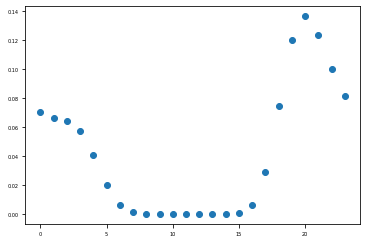

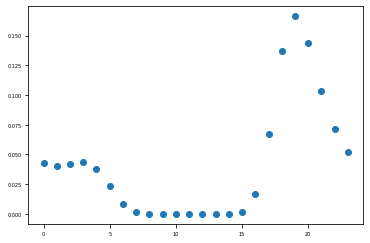

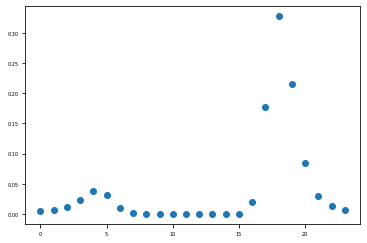

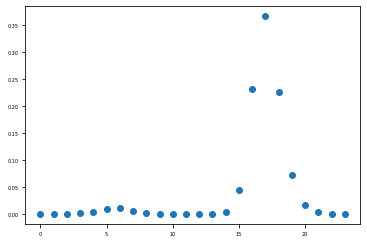

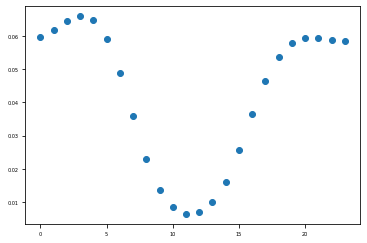

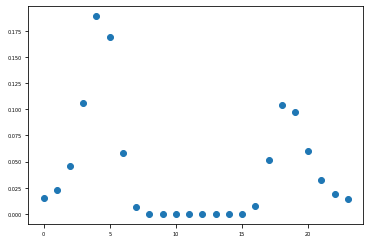

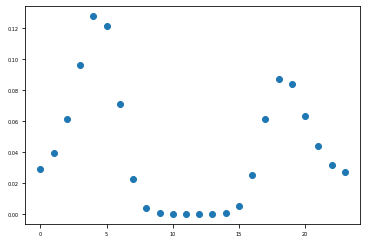

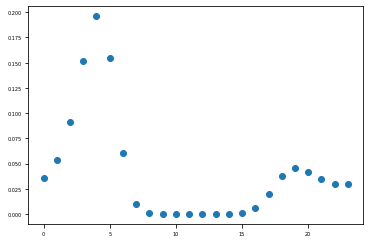

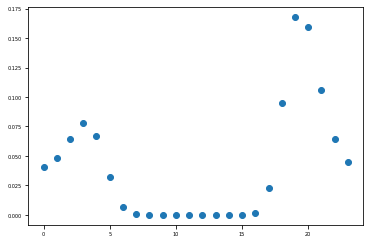

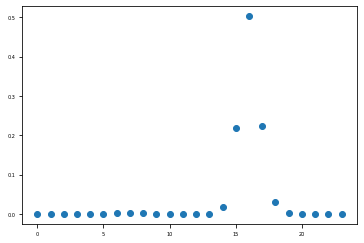

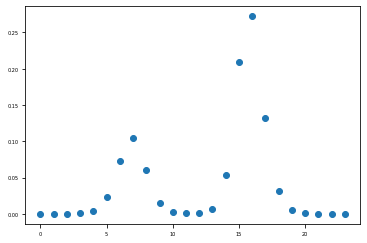

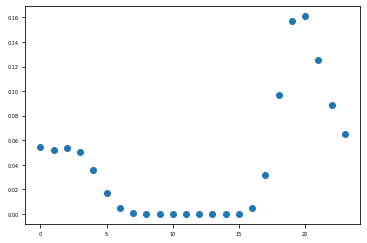

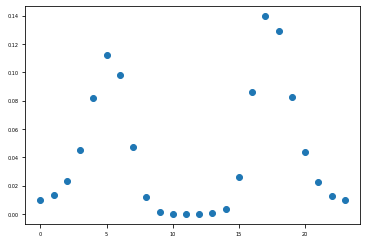

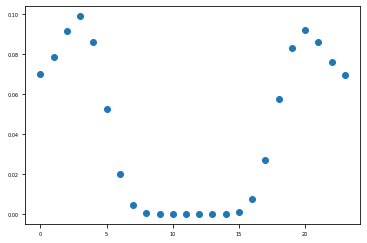

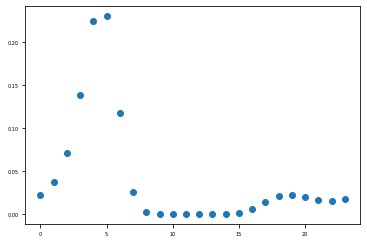

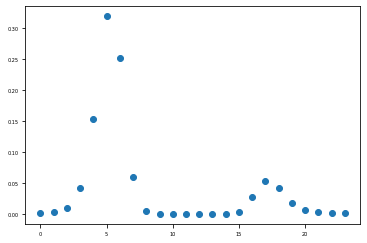

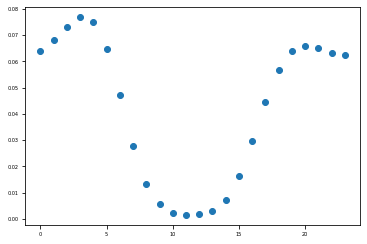

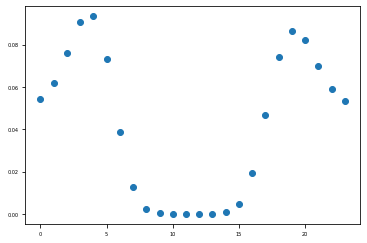

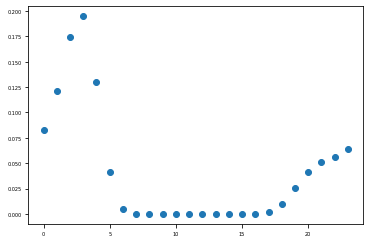

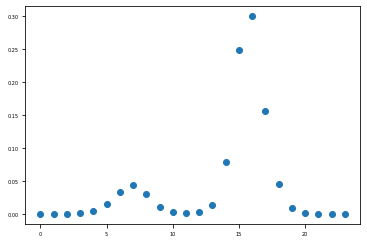

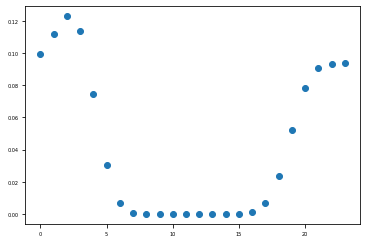

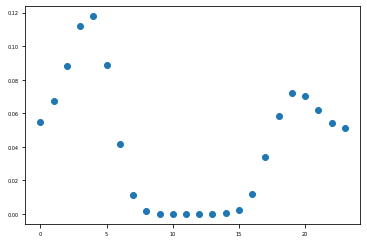

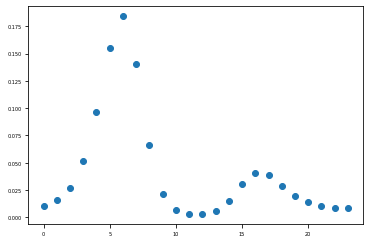

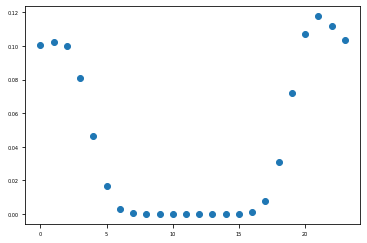

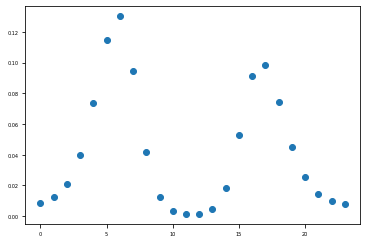

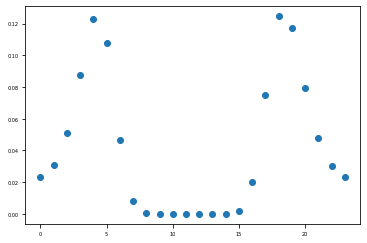

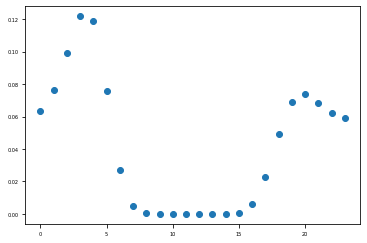

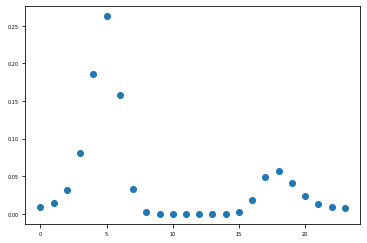

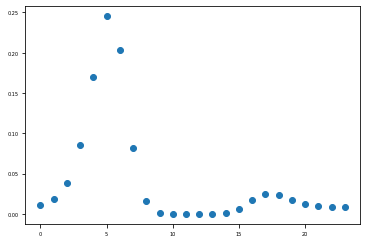

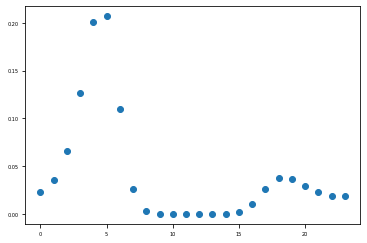

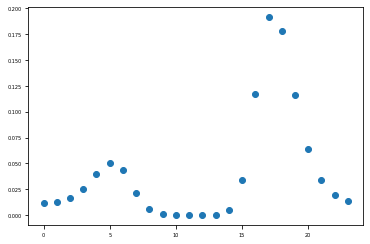

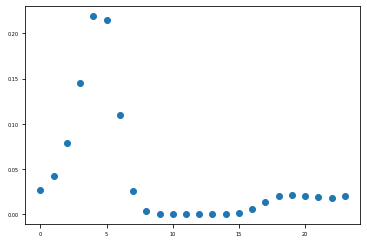

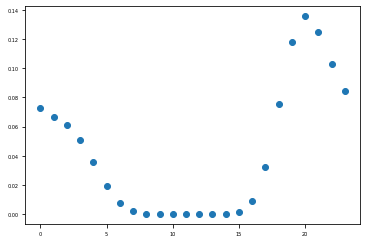

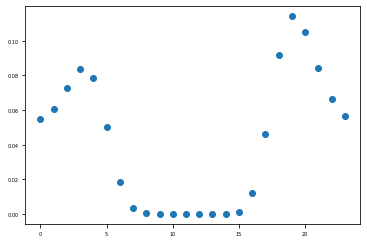

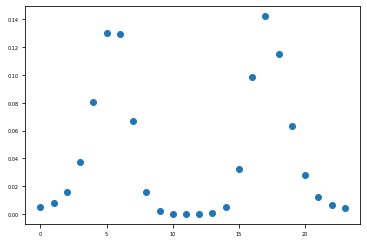

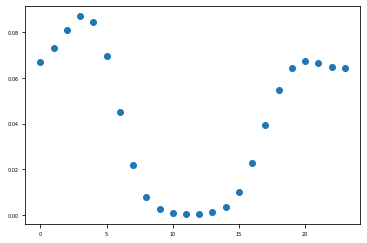

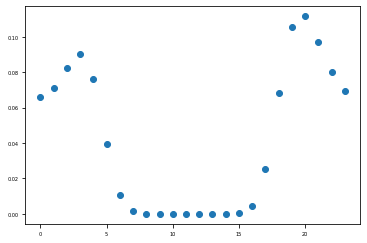

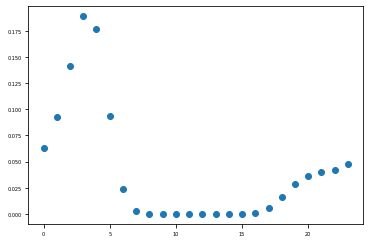

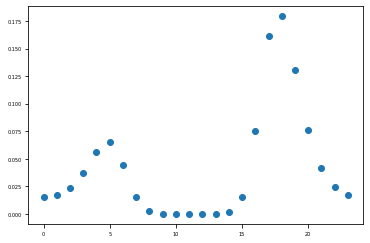

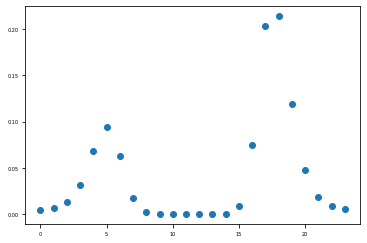

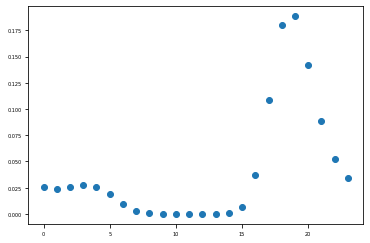

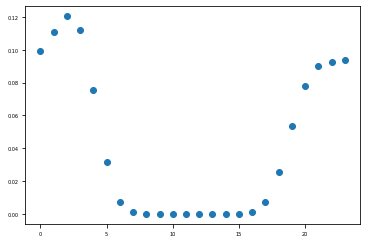

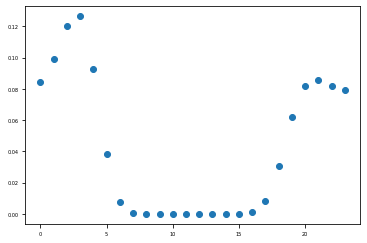

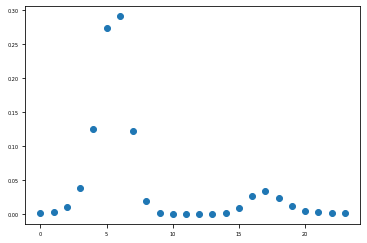

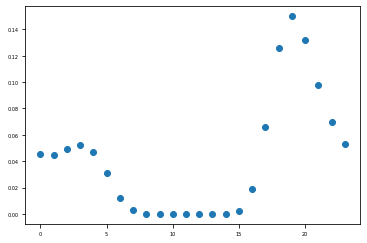

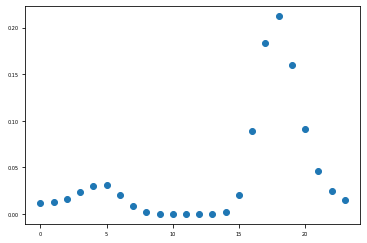

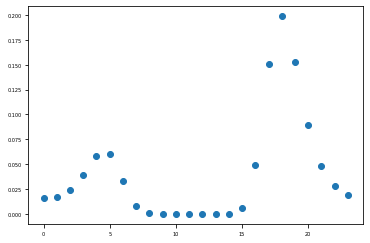

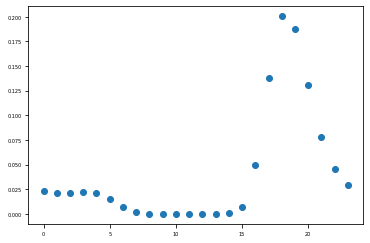

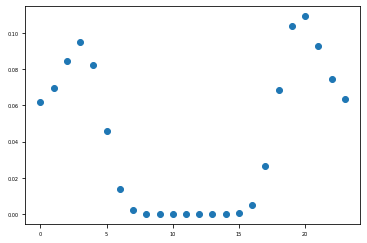

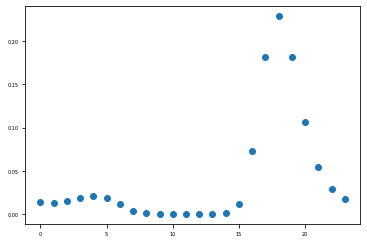

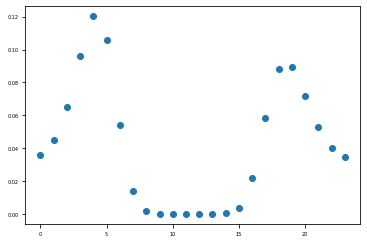

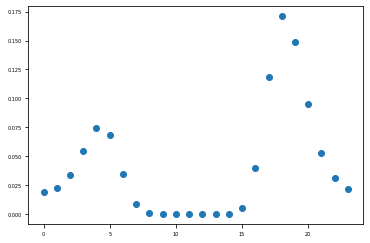

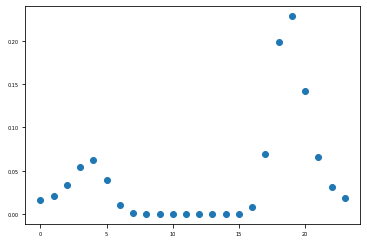

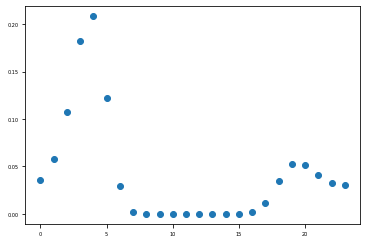

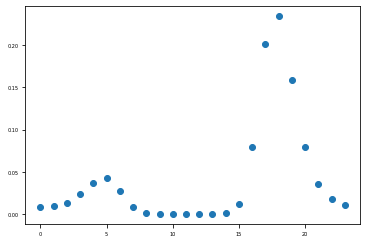

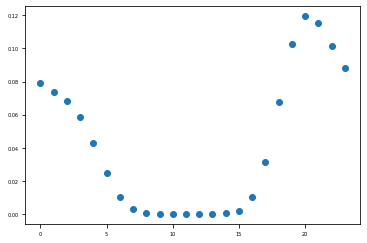

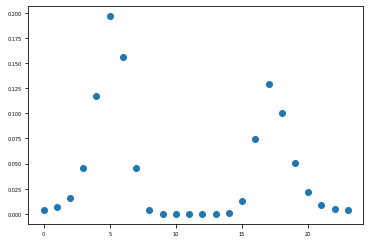

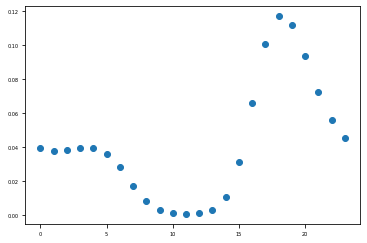

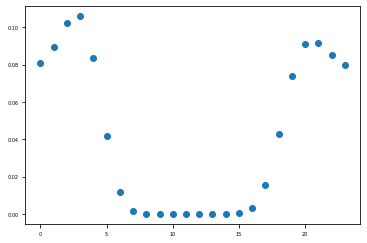

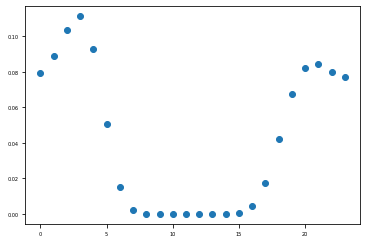

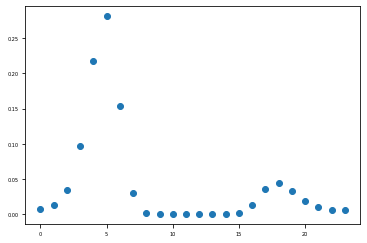

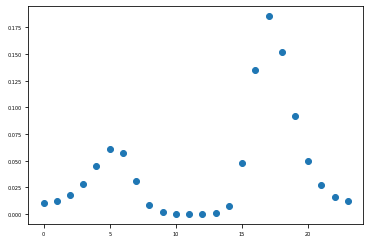

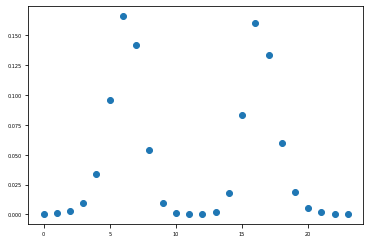

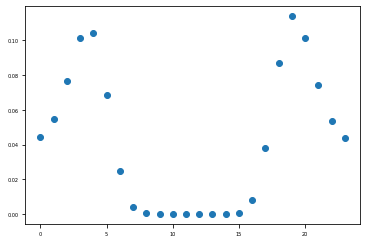

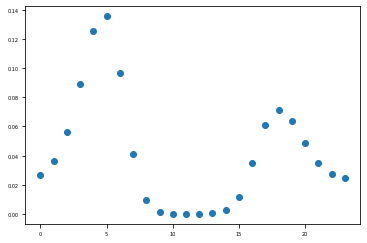

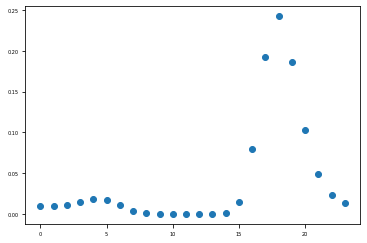

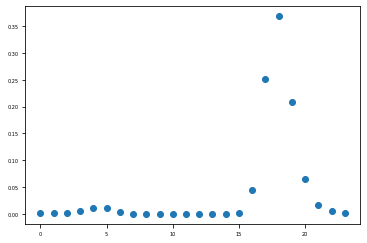

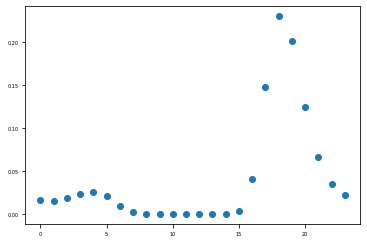

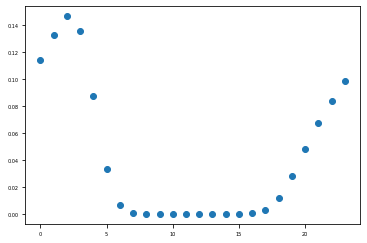

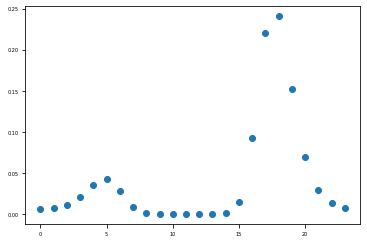

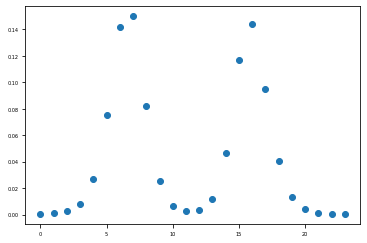

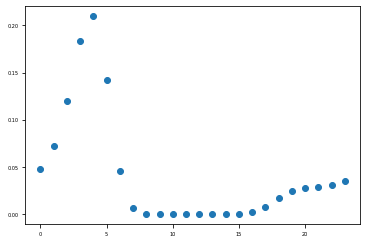

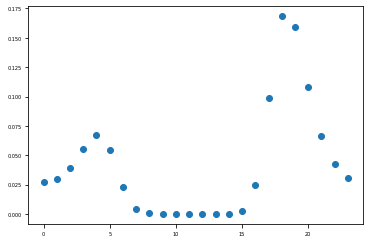

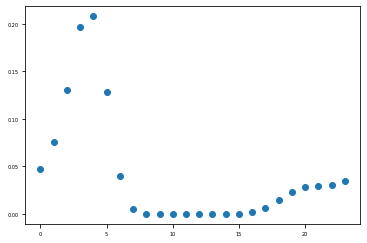

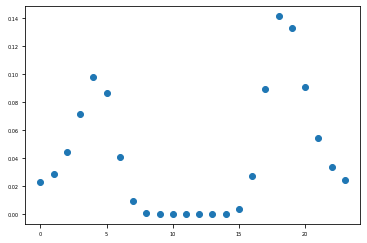

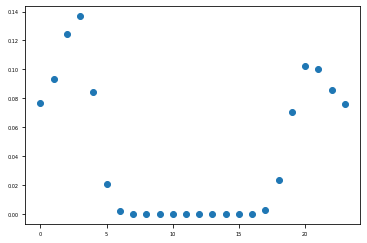

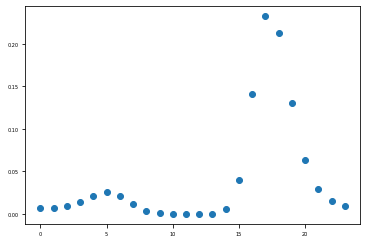

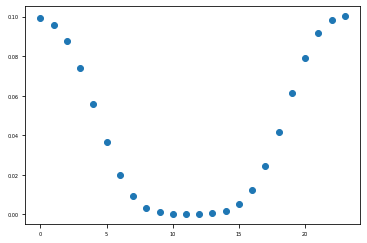

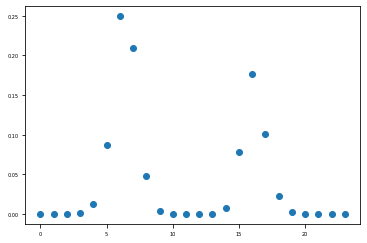

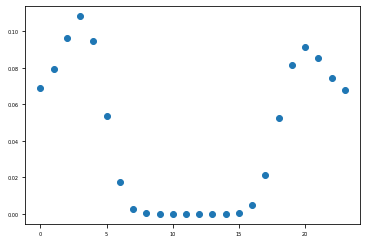

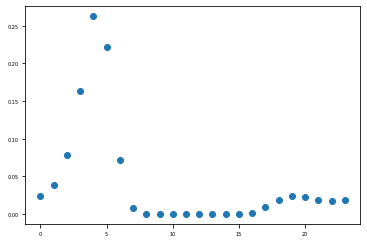

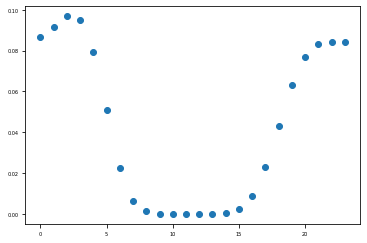

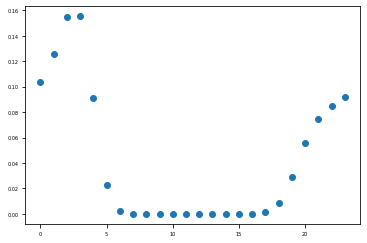

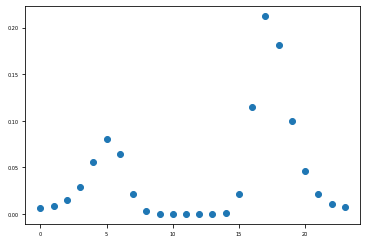

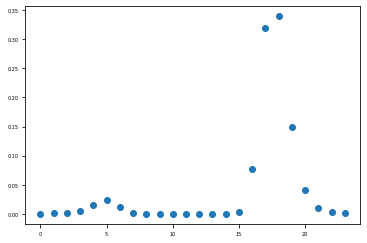

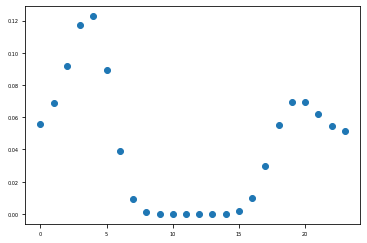

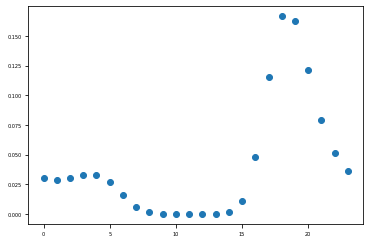

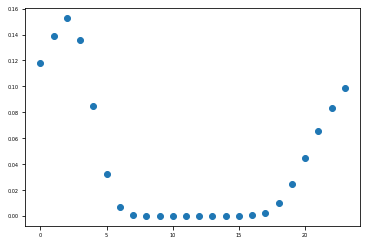

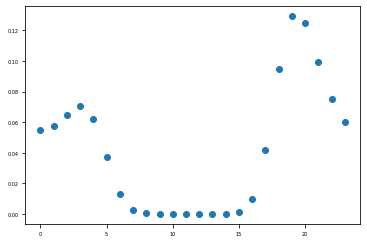

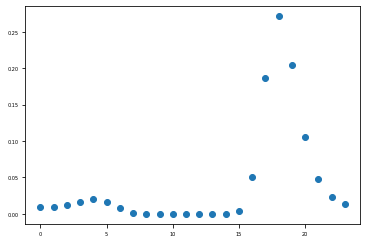

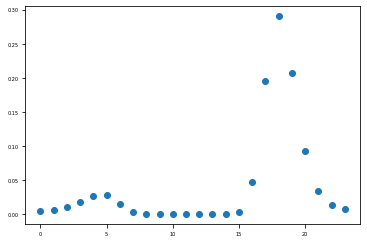

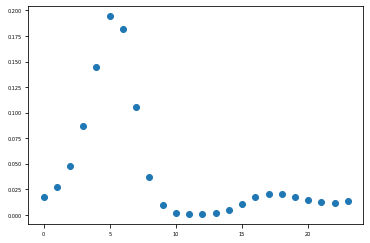

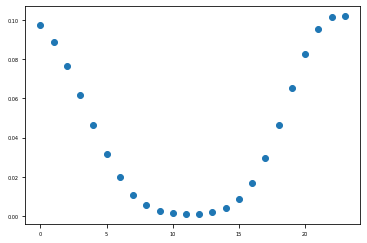

In [51]:
for cell_index in range(0,zt_posterior_df.shape[0]):
    plt.clf()
    plt.scatter(np.arange(0,24),zt_posterior_df.iloc[cell_index])
    plt.show()
    
    

In [55]:
(prob_a - prob_b) <= -1 / np.log10(np.e)

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False,  True, False,  True, False, False, False, False,
        False, False, False, False, False,  True,  True, False, False, False,
        False,  True, False,  True, False, False,  True,  True, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False,  True, False, False, False,  True,  True, False, False,
        False, False, False, False, False, False, False,  True, False,  True,
        False, False, False, False, False, False, False,  True, False, False,
        False, False, False, False,  True, False,  True, False, False,  True,
        False, False, False,  True, False,  True, False, False, False, False,
        False, False, False, False, False,  True, False, False, False, False,
        False, False, False, False, False, False,  True, False, False, False,
        False, False, False, False, False, False, False, False, 